# Выпускной проект. Промышленность

## Описание проекта. Промышленность

Чтобы оптимизировать производственные расходы, металлургический комбинат «Стальная птица» решил уменьшить потребление электроэнергии на этапе обработки стали. Для этого комбинату нужно контролировать температуру сплава. Ваша задача — построить модель, которая будет её предсказывать. Заказчик хочет использовать разработанную модель для имитации технологического процесса. Изучите его, прежде чем генерировать новые признаки.

### Описание процесса обработки
Сталь обрабатывают в металлическом ковше вместимостью около 100 тонн. Чтобы ковш выдерживал высокие температуры, изнутри его облицовывают огнеупорным кирпичом. Расплавленную сталь заливают в ковш и подогревают до нужной температуры графитовыми электродами. Они установлены на крышке ковша.
Сначала происходит десульфурация — из стали выводят серу и корректируют её химический состав добавлением примесей. Затем сталь легируют — добавляют в неё куски сплава из бункера для сыпучих материалов или порошковую проволоку через специальный трайб-аппарат.
Прежде чем в первый раз ввести легирующие добавки, специалисты производят химический анализ стали и измеряют её температуру. Потом температуру на несколько минут повышают, уже после этого добавляют легирующие материалы и продувают сталь инертным газом, чтобы перемешать, а затем снова проводят измерения. Такой цикл повторяется до тех пор, пока не будут достигнуты нужный химический состав стали и оптимальная температура плавки.
Дальше расплавленная сталь отправляется на доводку металла или поступает в машину непрерывной разливки. Оттуда готовый продукт выходит в виде заготовок-слябов (англ. slab, «плита»).

## Загрузка данных

In [129]:
%pip install phik -q
%pip install optuna -q
%pip install optuna_integration -q
%pip install catboost -q
%pip install catboost[gpu] -q

In [130]:
import os
import pandas as pd
import numpy as np

from sqlalchemy import create_engine, inspect, text

import matplotlib.pyplot as plt
import seaborn as sns

import phik

import functools

from scipy.stats import shapiro
from scipy.stats import spearmanr

from numpy.random import RandomState
from numpy import mean
from numpy import std

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import optuna
from optuna_integration import CatBoostPruningCallback
from catboost import Pool, cv

from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_absolute_error, root_mean_squared_error

from sklearn.model_selection import StratifiedKFold

from sklearn.model_selection import RandomizedSearchCV

from sklearn.tree import DecisionTreeRegressor

from sklearn.feature_selection import SelectKBest 
from sklearn.feature_selection import f_classif

from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from imblearn.pipeline import Pipeline

from catboost import CatBoostClassifier, Pool, cv

try:
	from google.colab import drive
	colab = True
	print('Проект выполняется в Colab')
except:
	colab= False
	print('Проект выполняется не в Colab')

Проект выполняется в Colab


In [131]:
path_to_db = 'ds-plus-final.db'
try:
	if colab==False:
		engine = create_engine(f'sqlite:///{path_to_db}', echo=False)
	else:
		drive.mount('/content/drive')
		base_path = '/content/drive/MyDrive/Colab Notebooks/project_f1/'
		path_to_db = base_path + path_to_db
		engine = create_engine(f'sqlite:///{path_to_db}', echo=False)

except:
	!wget https://code.s3.yandex.net/data-scientist/ds-plus-final.db 
	engine = create_engine(f'sqlite:///{path_to_db}', echo=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [132]:
RANDOM_STATE= 200726
state = RandomState(RANDOM_STATE)
TEST_SIZE= 0.25
plt.rcParams["figure.figsize"] = (12,6)

### Пользовательские функции

In [133]:
def df_hist(df, bins=20, id=1):

    # Удаление столбца id из датафрейма для создания графиков
    if id:
        df = df.drop(columns=['key'])

    # Определение целочисленных столбцов 
    count_col = df.select_dtypes('number')
    count_col = count_col.columns[count_col.nunique() < 11]

    # Создание гистограммы и boxplot для непрерывных данных
    for col in df.select_dtypes('number').drop(columns=count_col):
        fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2,figsize=(12,6))
        df[col].hist(bins=bins, ax=ax1)
        ax1.set_title(f'Гистограмма по столбцу "{col}"')
        ax1.set_xlabel(col)
        ax1.set_ylabel('Количество')
        df.boxplot(column=col, ax=ax2, vert=False)
        ax2.tick_params(axis='y', which='both', left=False, labelleft=False)
        ax2.set_title(f'Ящик с усами по столбцу "{col}"')
        plt.xlabel(col)
        plt.show();

    # Создание countplot для целочесленных данных
    for col in df[count_col]:
        sns.countplot(data=df, x=col)
        plt.grid(True)
        plt.ylabel('Количество')
        plt.xlabel(col)
        plt.title(f'Диаграмма по столбцу "{col}"')
        plt.show();

    # Создание countplot для категориальных данных
    for col in df.select_dtypes('object'):
        sns.countplot(data=df, x=col)
        if df[col].nunique() > 3:
            plt.xticks(rotation=90)
        plt.grid(True)
        plt.ylabel('Количество')
        plt.xlabel(col)
        plt.title(f'Диаграмма по столбцу "{col}"')
        plt.show();

	# Создание гистограммы и boxplot для datetime
    for col in df.select_dtypes('datetime64[ns]'):
        df[col].hist(bins=bins)
        plt.title(f'Гистограмма по столбцу "{col}"')
        plt.xlabel(col)
        plt.ylabel('Количество')
        plt.xticks(rotation=90)
        plt.show();

In [134]:
def df_corr(df, continuous_features=None):
	if continuous_features is None:
		continuous_features = df.select_dtypes('number').columns
	if len(df.columns) > 1:
		plt.figure(figsize=(30,30));
		ax = sns.heatmap(df.phik_matrix(interval_cols=continuous_features), annot=True, fmt='.2f', cmap='coolwarm');
		ax.set(xlabel="", ylabel="", title=f'Корреляционная матрица датафрейма')
		plt.show();

In [135]:
def df_corr(df, continuous_features=None):
    if continuous_features is None:
        continuous_features = df.select_dtypes(include=['number']).columns.tolist()

    spearman_corr = df[continuous_features].corr(method='spearman')
    
    plt.figure(figsize=(30, 30))
    ax = sns.heatmap(
        spearman_corr,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8}
    )
    ax.set(xlabel="", ylabel="", title='Матрица корреляции Спирмена')
    plt.show()

## Анализ таблиц

In [136]:
inspector = inspect(engine)
tables = inspector.get_table_names()

print(f"Найдено таблиц: {len(tables)}\n")
for table in tables:
	with engine.connect() as conn:
		count_query = text(f"SELECT COUNT(*) FROM {table}")
		result = conn.execute(count_query)
		row_count = result.scalar()
	
	status = "есть данные" if row_count > 0 else "пустая"
	print(f"Таблица '{table}': {status} (строк: {row_count})")

Найдено таблиц: 11

Таблица 'contract': есть данные (строк: 7043)
Таблица 'data_arc': есть данные (строк: 14876)
Таблица 'data_bulk': есть данные (строк: 3129)
Таблица 'data_bulk_time': есть данные (строк: 3129)
Таблица 'data_gas': есть данные (строк: 3239)
Таблица 'data_temp': есть данные (строк: 18092)
Таблица 'data_wire': есть данные (строк: 3081)
Таблица 'data_wire_time': есть данные (строк: 3081)
Таблица 'internet': есть данные (строк: 5517)
Таблица 'personal': есть данные (строк: 7043)
Таблица 'phone': есть данные (строк: 6361)


In [137]:
def query(txt):
    with engine.connect() as conn:
        count_query = text(txt)
        result = conn.execute(count_query).fetchall()
        result = pd.DataFrame(result)
    return result

### Таблица steel.data_arc

Проведите исследовательский анализ данных: проверьте наличие пропусков и аномалий, изучите распределение признаков.

Вам нужно либо удалить всю партию с аномальным значением, либо заменить аномальное значение, основываясь на нормальных наблюдениях.

Попробуйте сгенерировать новые признаки, которые могут пригодиться при обучении: длительность нагрева, общую мощность, соотношение активной мощности к реактивной, количество запуска нагрева электродами и другие.

При агрегировании наблюдений по ключу учитывайте порядок арифметических действий: сначала сгенерируйте новые признаки, затем уже агрегируйте наблюдения.

In [138]:
query(txt="SELECT * FROM data_arc \
            LIMIT 5")

,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691


In [139]:
df_data_arc = query(txt="SELECT * FROM data_arc")

In [140]:
df_data_arc['Начало нагрева дугой'] = pd.to_datetime(df_data_arc['Начало нагрева дугой'])
df_data_arc['Конец нагрева дугой'] = pd.to_datetime(df_data_arc['Конец нагрева дугой'])

In [141]:
df_data_arc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   key                   14876 non-null  int64         
 1   Начало нагрева дугой  14876 non-null  datetime64[ns]
 2   Конец нагрева дугой   14876 non-null  datetime64[ns]
 3   Активная мощность     14876 non-null  float64       
 4   Реактивная мощность   14876 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(1)
memory usage: 581.2 KB


Пропущенные значения отсутствуют

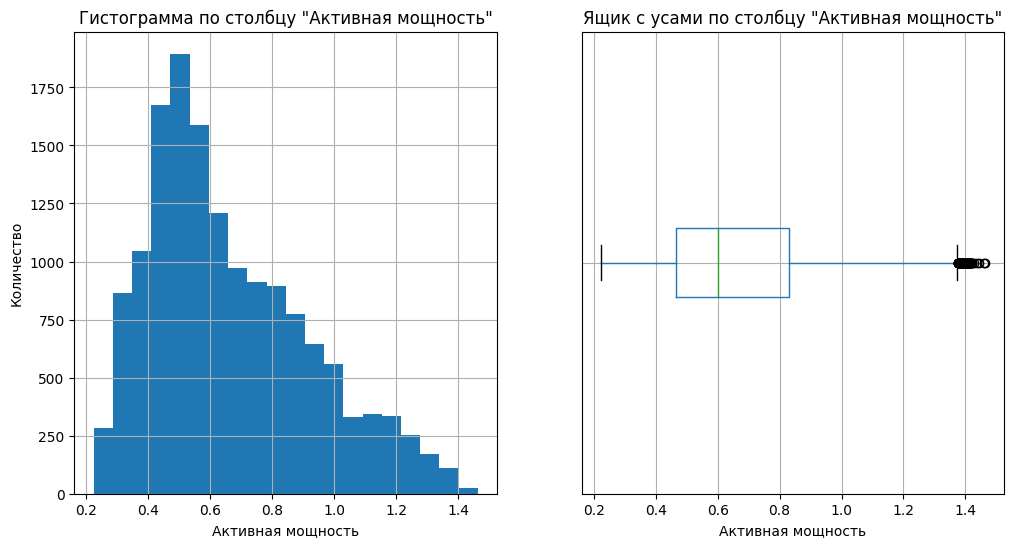

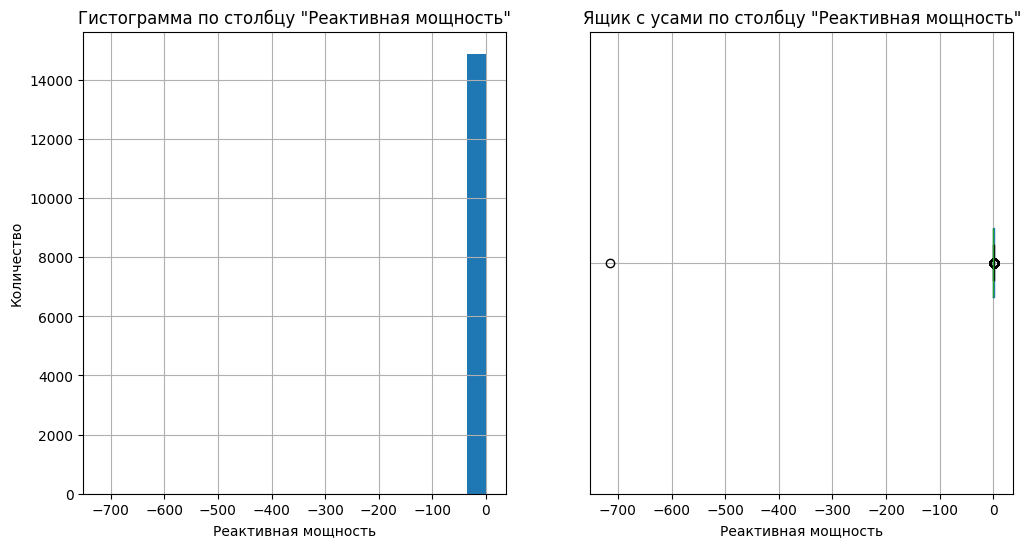

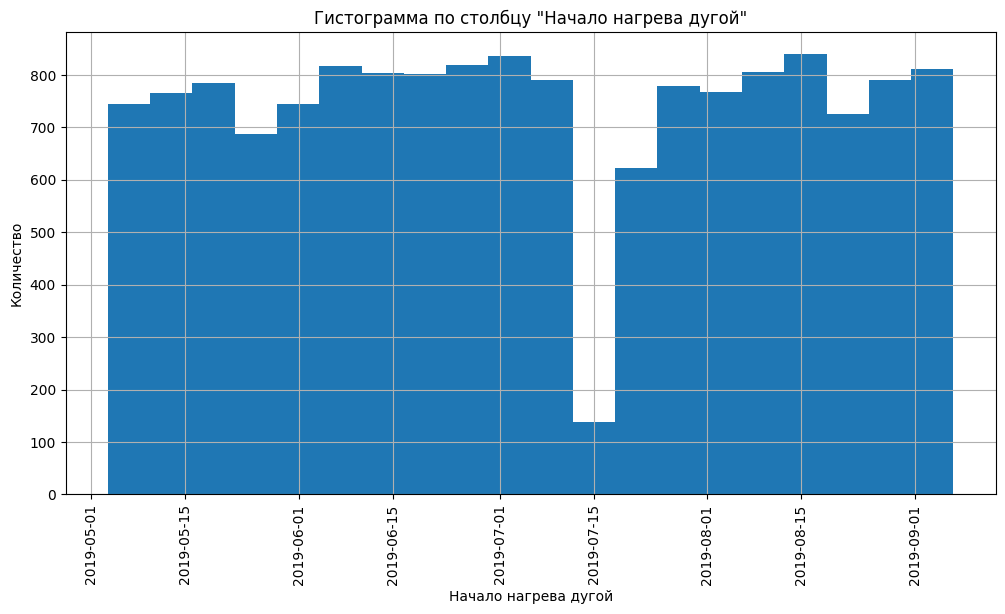

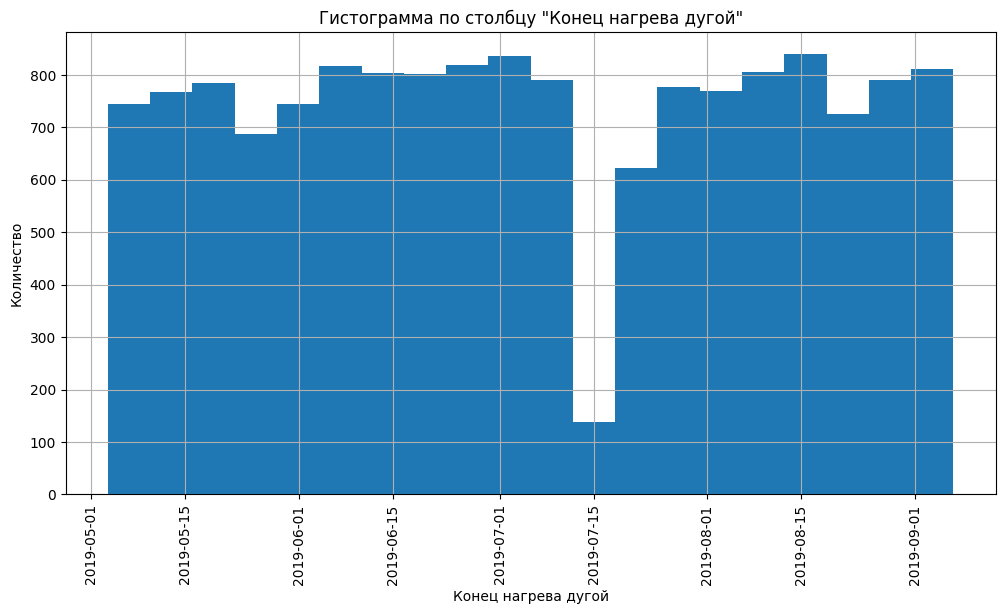

In [142]:
df_hist(df_data_arc)

In [143]:
keys = df_data_arc[df_data_arc['Реактивная мощность'] < 0]['key']
print(keys.values)
df_data_arc = df_data_arc[~df_data_arc['key'].isin(keys.values)]

[2116]


<Axes: >

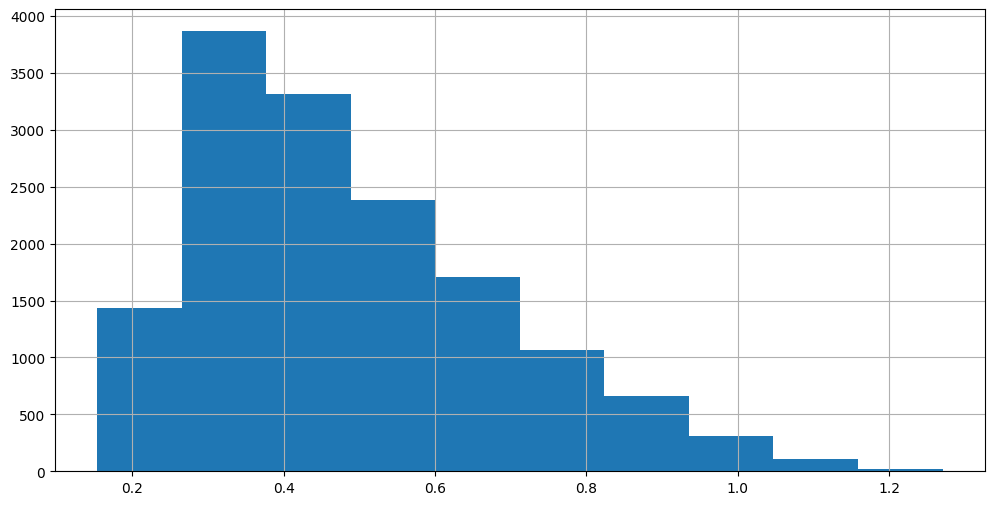

In [144]:
df_data_arc['Реактивная мощность'].hist()

In [145]:
df_data_arc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14872 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   key                   14872 non-null  int64         
 1   Начало нагрева дугой  14872 non-null  datetime64[ns]
 2   Конец нагрева дугой   14872 non-null  datetime64[ns]
 3   Активная мощность     14872 non-null  float64       
 4   Реактивная мощность   14872 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(1)
memory usage: 697.1 KB


#### Создание новых признаков

In [146]:
df_data_arc['Длительность нагрева'] = (df_data_arc['Конец нагрева дугой'] - df_data_arc['Начало нагрева дугой']).dt.total_seconds().astype('int')

In [147]:
df_data_arc['Общая мощность'] = (df_data_arc['Активная мощность'] + df_data_arc['Реактивная мощность']).round(6)

In [148]:
df_data_arc['Отношение мощностей'] = (df_data_arc['Реактивная мощность'] / df_data_arc['Активная мощность']).round(6)

In [149]:
df_data_arc.head(5)

,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность,Длительность нагрева,Общая мощность,Отношение мощностей
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,228,0.516383,0.692338
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185,1.243096,0.623566
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460,172,1.010773,0.741772
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979,365,0.898475,0.732848
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691,148,1.510824,0.742321


In [150]:
df_data_arc = df_data_arc.groupby('key').agg(
    count_usage=('key','count'),
    active_mean_power=('Активная мощность','mean'),
    react_mean_power=('Реактивная мощность','mean'),
    mean_power=('Общая мощность','mean'),
    total_duration=('Длительность нагрева','sum'),
    mean_duration=('Длительность нагрева','mean')
    )

In [151]:
df_data_arc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3213 entries, 1 to 3241
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   count_usage        3213 non-null   int64  
 1   active_mean_power  3213 non-null   float64
 2   react_mean_power   3213 non-null   float64
 3   mean_power         3213 non-null   float64
 4   total_duration     3213 non-null   int64  
 5   mean_duration      3213 non-null   float64
dtypes: float64(4), int64(2)
memory usage: 175.7 KB


In [152]:
df_data_arc.head(5)

,count_usage,active_mean_power,react_mean_power,mean_power,total_duration,mean_duration
key,,,,,,
1,5,0.607346,0.428564,1.035910,1098,219.60
2,4,0.534852,0.363339,0.898191,811,202.75
3,5,0.812728,0.587491,1.400220,655,131.00
4,4,0.676622,0.514248,1.190870,741,185.25
5,4,0.563238,0.421998,0.985235,869,217.25


#### Промежуточный вывод

В таблице steel_ark присутствовала 1 аномалия. Данная строка была удалена.

Также были добавлены новые признаки: длительность нагрева, общая мощность, отношение реактивной мощности к активной

### Таблица steel.data_bulk

Проведите исследовательский анализ данных: проверьте наличие пропусков и аномалий, изучите распределение признаков.

Обработайте пропуски. Пропуск означает, что материал не добавляли в партию.

In [153]:
query(txt="SELECT * FROM data_bulk \
            LIMIT 5")

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,None,None,None,43.0,None,None,None,None,None,None,None,206.0,None,150.0,154.0
1,2,None,None,None,73.0,None,None,None,None,None,None,None,206.0,None,149.0,154.0
2,3,None,None,None,34.0,None,None,None,None,None,None,None,205.0,None,152.0,153.0
3,4,None,None,None,81.0,None,None,None,None,None,None,None,207.0,None,153.0,154.0
4,5,None,None,None,78.0,None,None,None,None,None,None,None,203.0,None,151.0,152.0


In [154]:
df_data_bulk = query(txt="SELECT * FROM data_bulk")

In [155]:
df_data_bulk.fillna(0, inplace=True)

In [156]:
for col in df_data_bulk.columns:
    df_data_bulk[col] = pd.to_numeric(df_data_bulk[col])

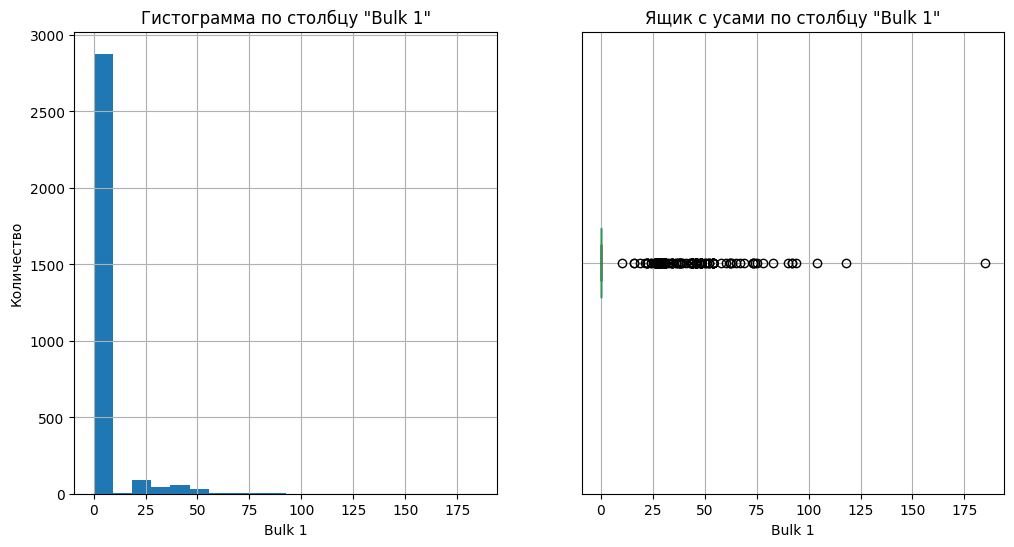

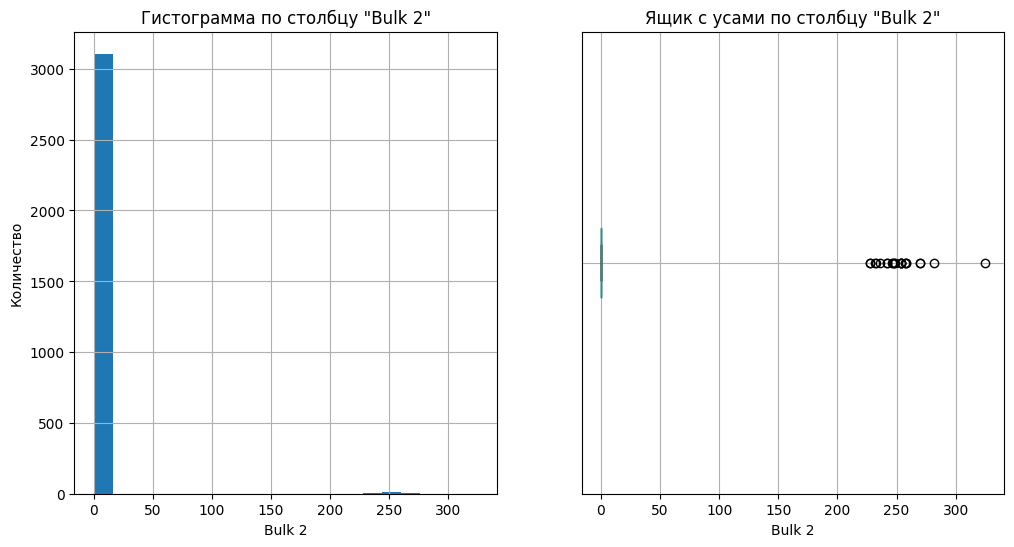

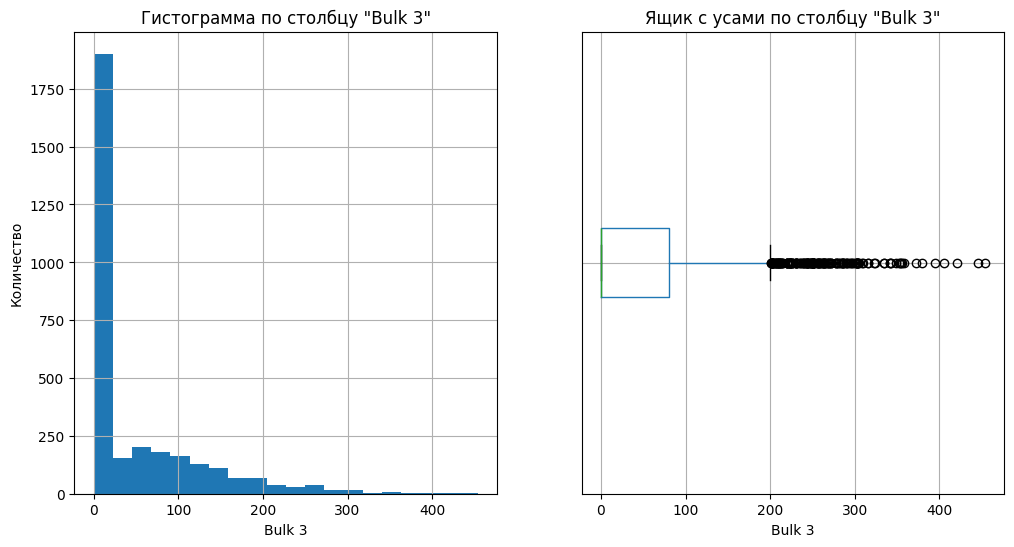

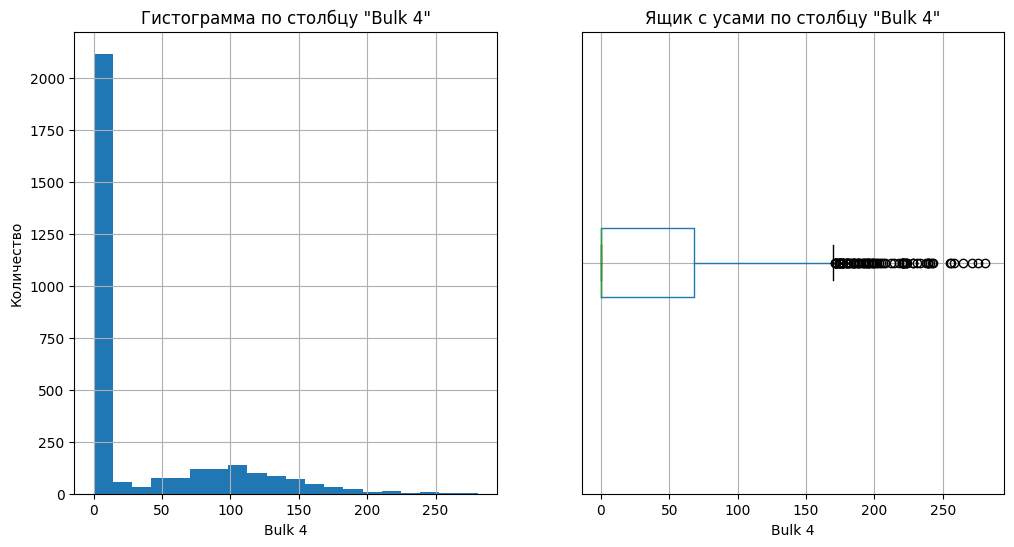

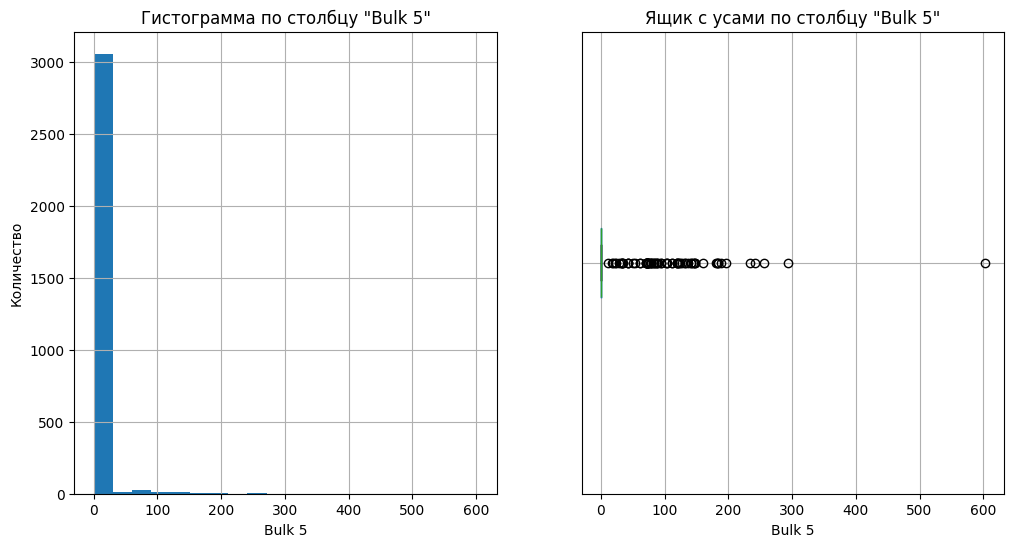

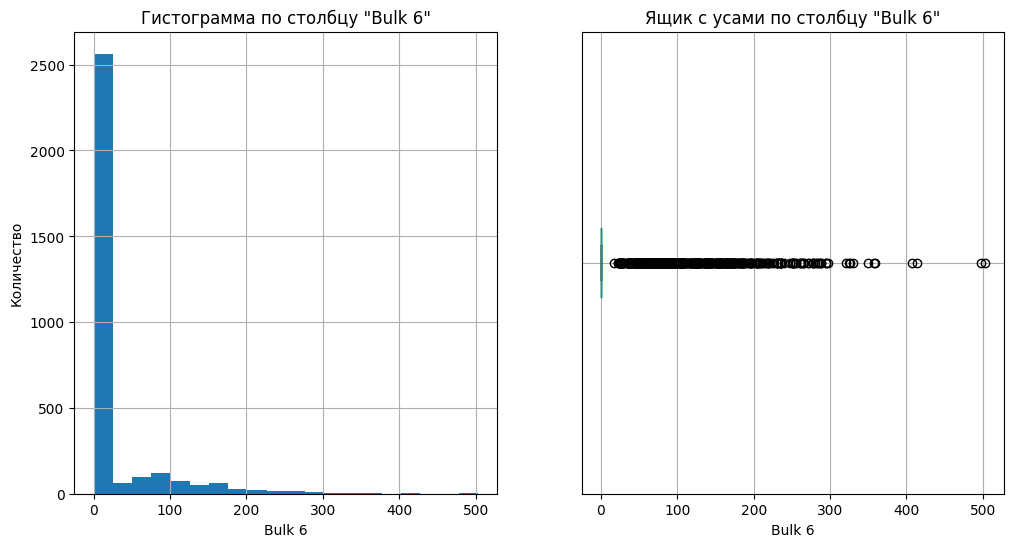

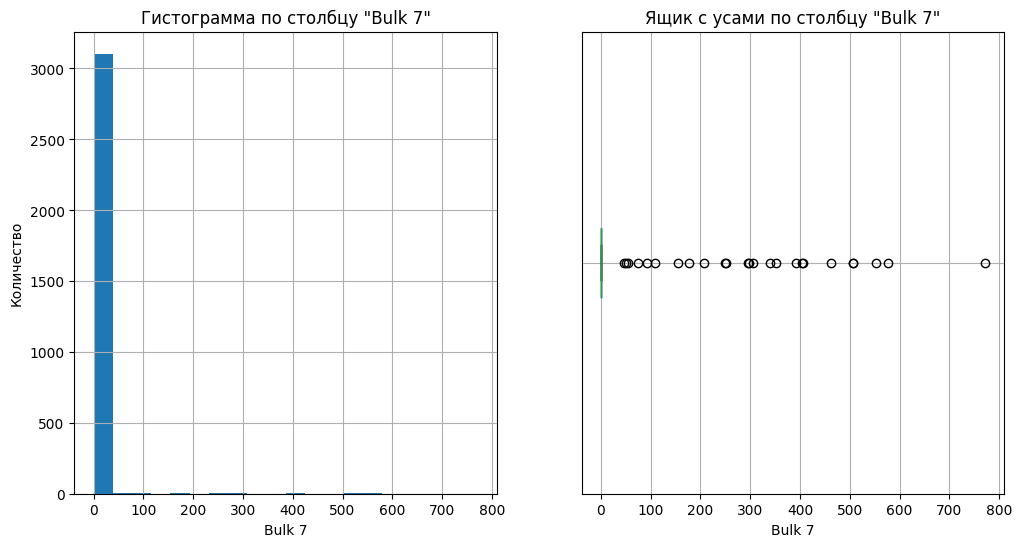

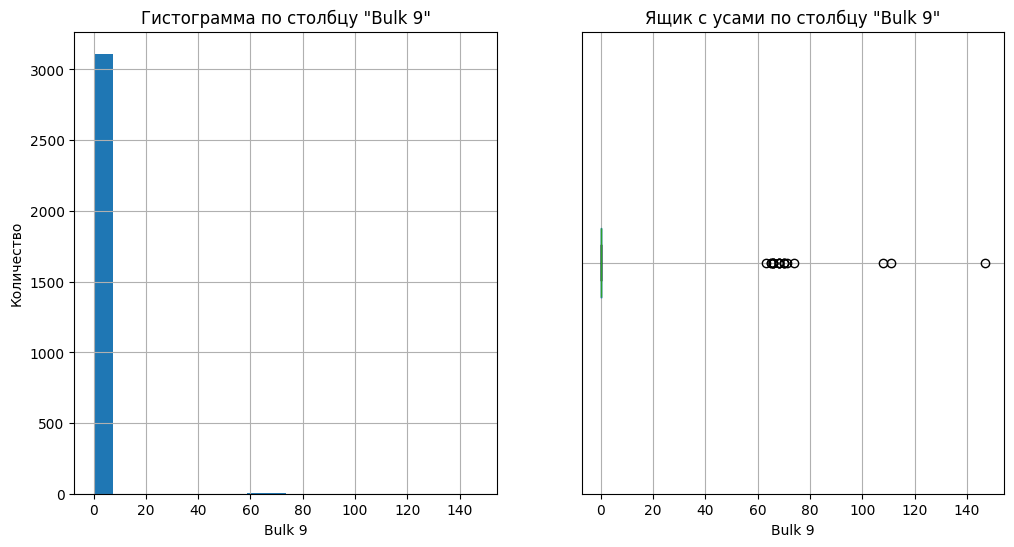

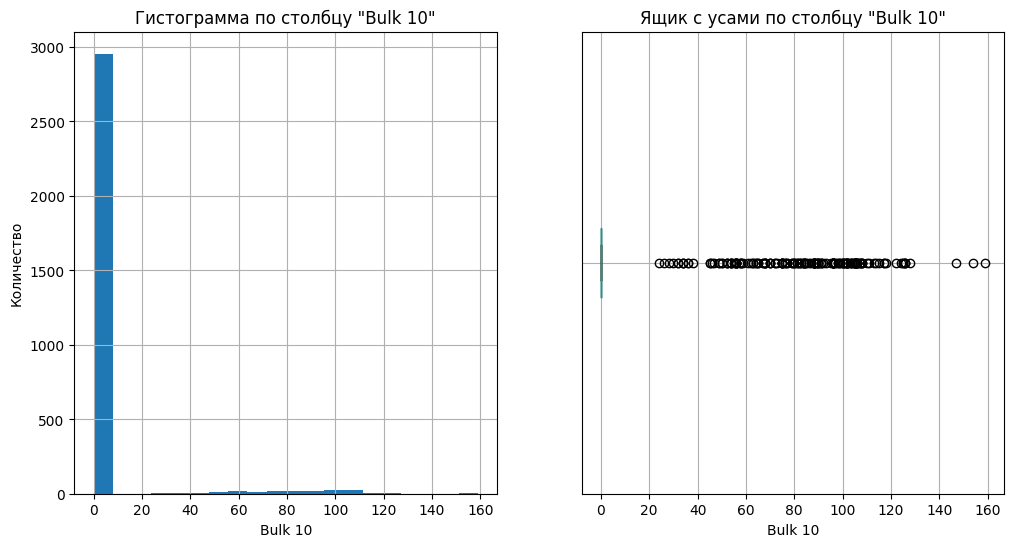

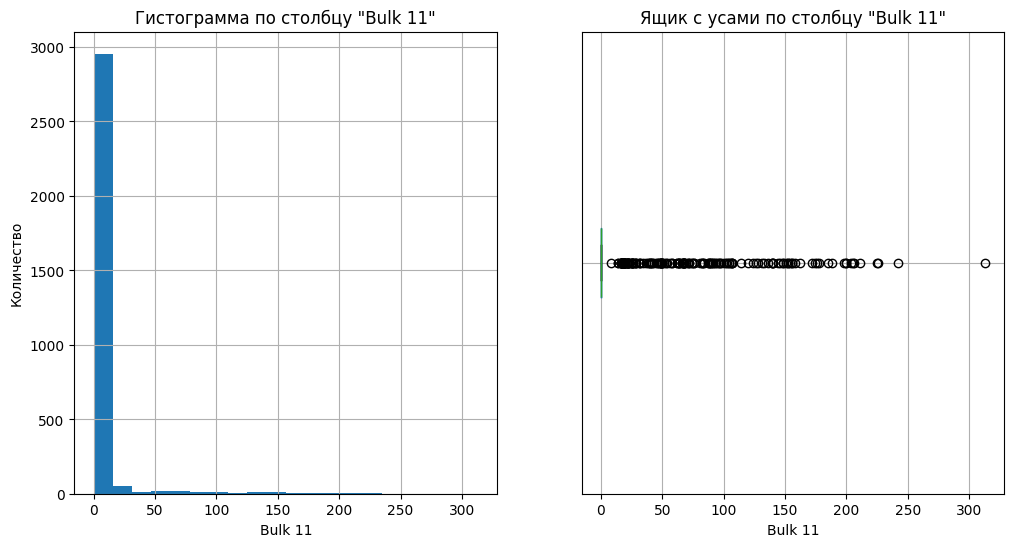

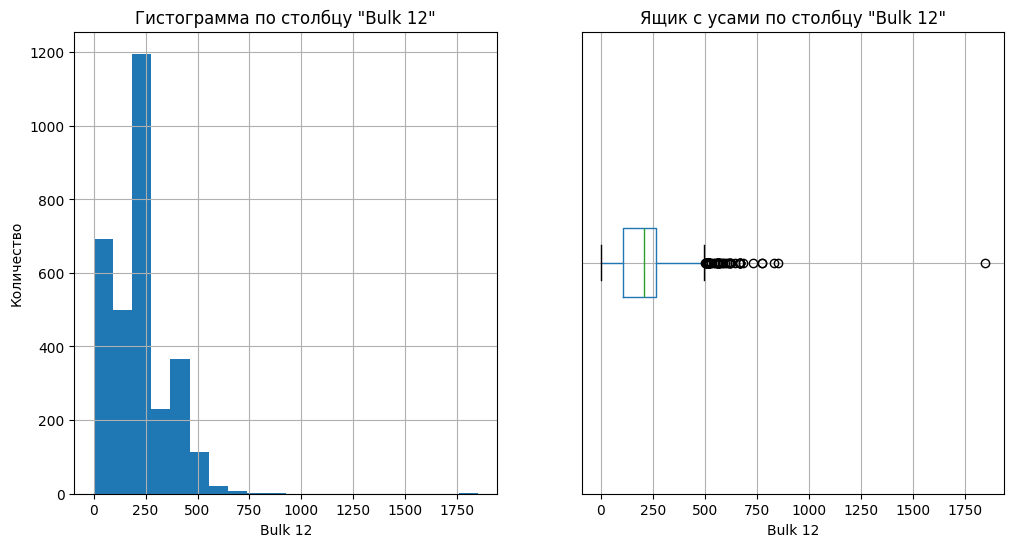

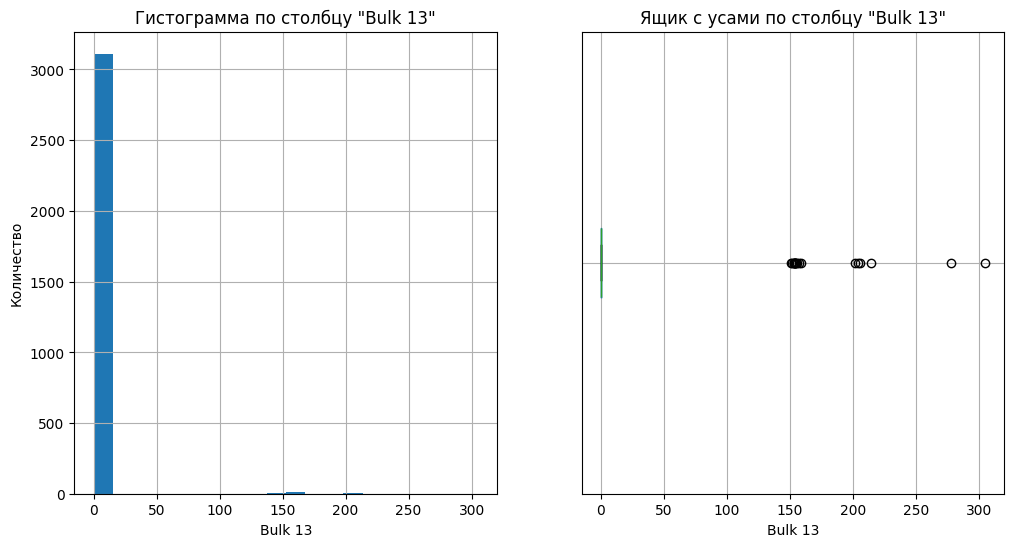

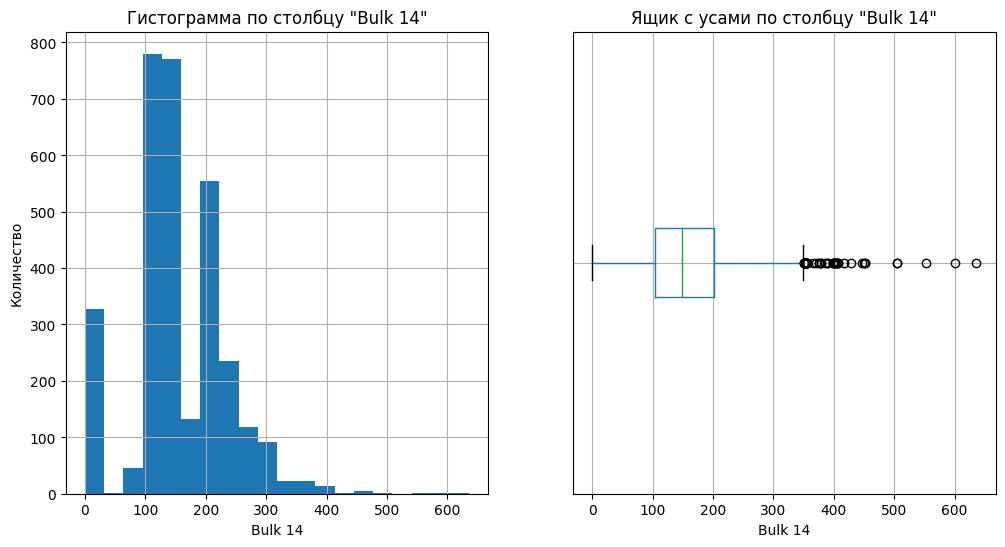

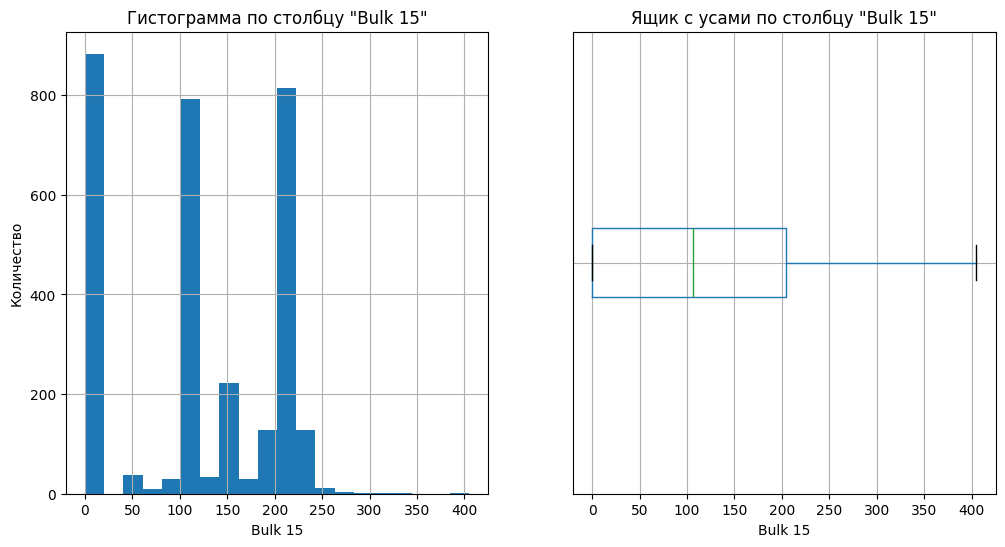

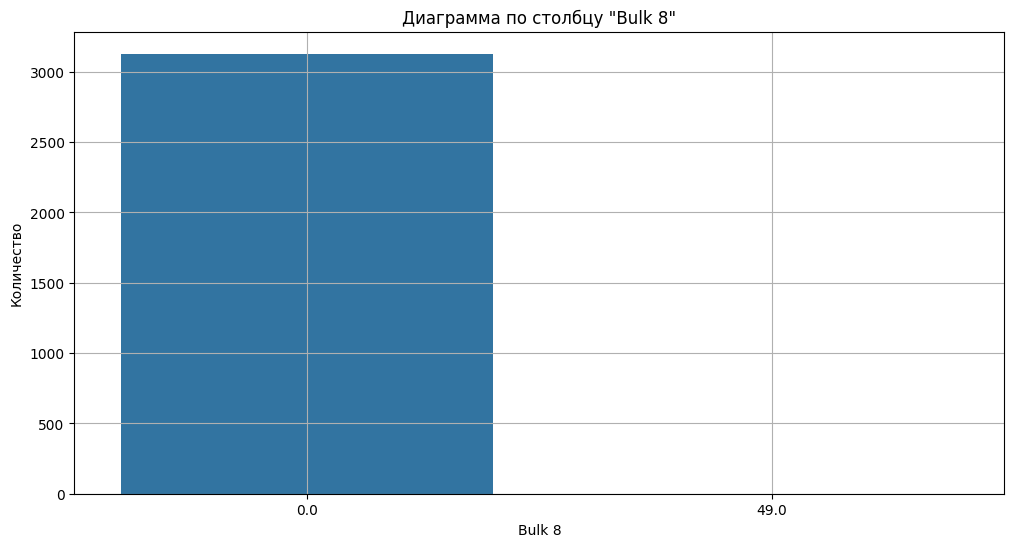

In [157]:
df_hist(df_data_bulk)

In [158]:
df_data_bulk[df_data_bulk['Bulk 12']>1000] = df_data_bulk['Bulk 12'].median()

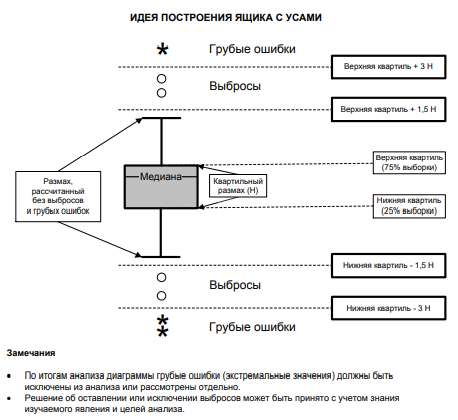

In [159]:
df_data_bulk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   Bulk 1   3129 non-null   float64
 2   Bulk 2   3129 non-null   float64
 3   Bulk 3   3129 non-null   float64
 4   Bulk 4   3129 non-null   float64
 5   Bulk 5   3129 non-null   float64
 6   Bulk 6   3129 non-null   float64
 7   Bulk 7   3129 non-null   float64
 8   Bulk 8   3129 non-null   float64
 9   Bulk 9   3129 non-null   float64
 10  Bulk 10  3129 non-null   float64
 11  Bulk 11  3129 non-null   float64
 12  Bulk 12  3129 non-null   float64
 13  Bulk 13  3129 non-null   float64
 14  Bulk 14  3129 non-null   float64
 15  Bulk 15  3129 non-null   float64
dtypes: float64(15), int64(1)
memory usage: 391.3 KB


<Axes: >

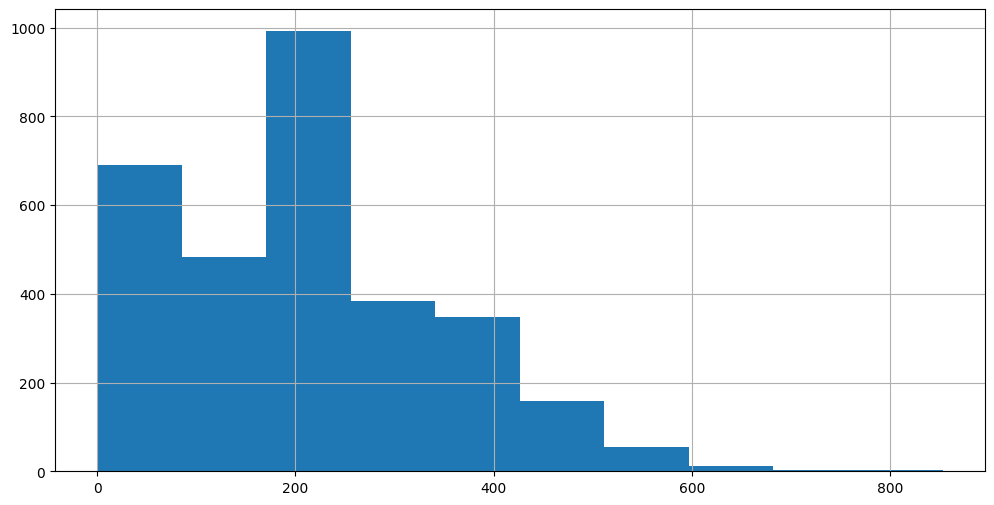

In [160]:
df_data_bulk['Bulk 12'].hist()

#### Промежуточный вывод

Исходя из гистограмм имеются незначительные выбросы, кроме Bulk_12, где выброс значителен по отношению к большому количеству дргуих значений. Данное значение приведено к медианному

### Таблица steel.data_bulk_time

Проведите исследовательский анализ данных: проверьте наличие пропусков и аномалий, изучите распределение признаков.

Проверьте данные на адекватность: например, убедитесь, что подача материала не измеряется сутками. Обратите внимание: перед вами не стоит задача временных рядов.

In [161]:
query(txt="SELECT * FROM data_bulk_time \
            LIMIT 5")

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,None,None,None,2019-05-03 11:28:48,None,None,None,None,None,None,None,2019-05-03 11:24:31,None,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2,None,None,None,2019-05-03 11:36:50,None,None,None,None,None,None,None,2019-05-03 11:53:30,None,2019-05-03 11:48:37,2019-05-03 11:44:39
2,3,None,None,None,2019-05-03 12:32:39,None,None,None,None,None,None,None,2019-05-03 12:27:13,None,2019-05-03 12:21:01,2019-05-03 12:16:16
3,4,None,None,None,2019-05-03 12:43:22,None,None,None,None,None,None,None,2019-05-03 12:58:00,None,2019-05-03 12:51:11,2019-05-03 12:46:36
4,5,None,None,None,2019-05-03 13:30:47,None,None,None,None,None,None,None,2019-05-03 13:30:47,None,2019-05-03 13:34:12,2019-05-03 13:30:47


In [162]:
df_data_bulk_time = query(txt="SELECT * FROM data_bulk_time")

In [163]:
for col in df_data_bulk_time.drop(columns=['key']).columns:
	df_data_bulk_time[col] = pd.to_datetime(df_data_bulk_time[col], errors='coerce')

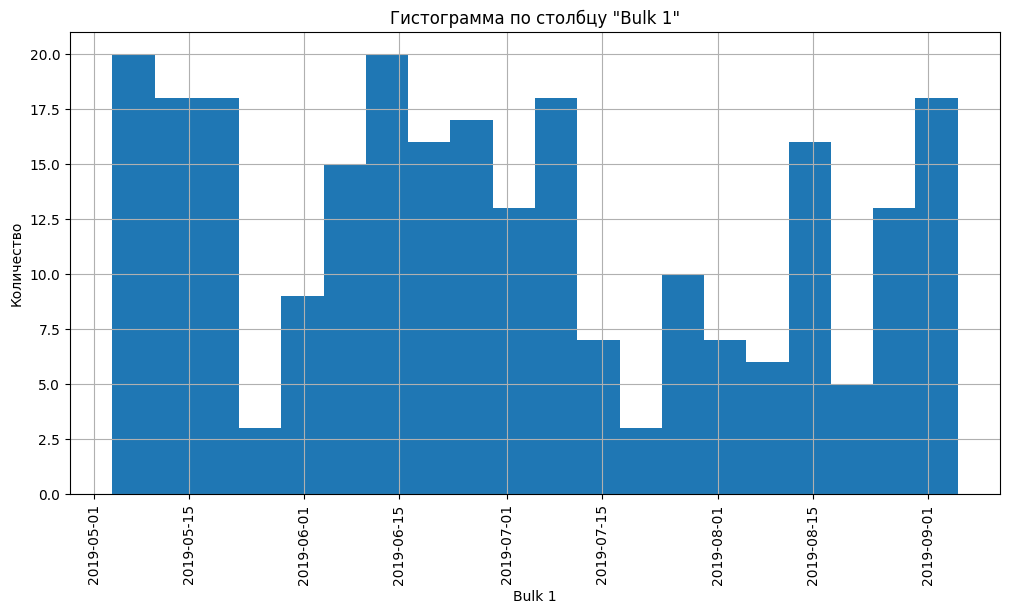

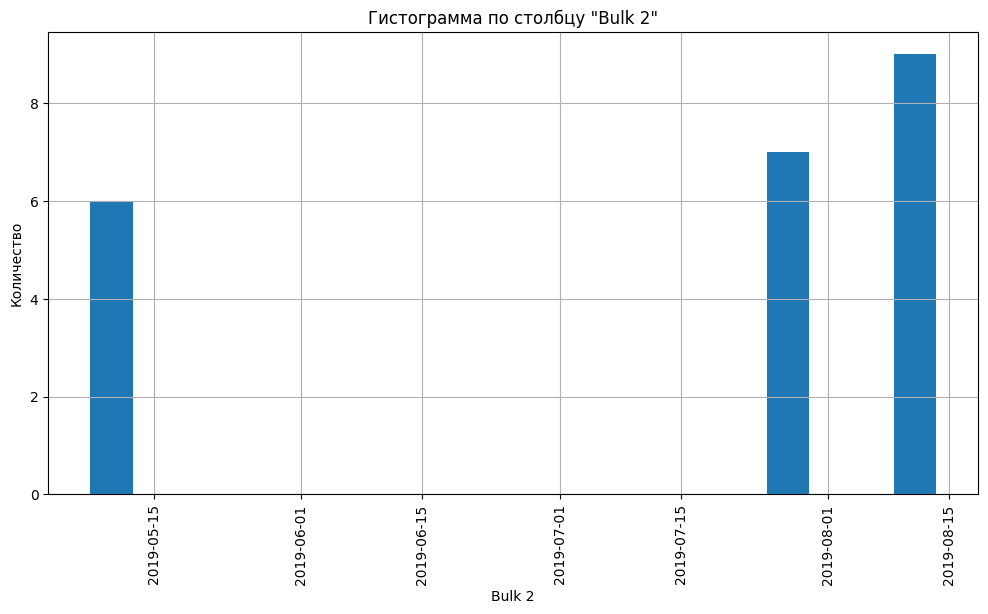

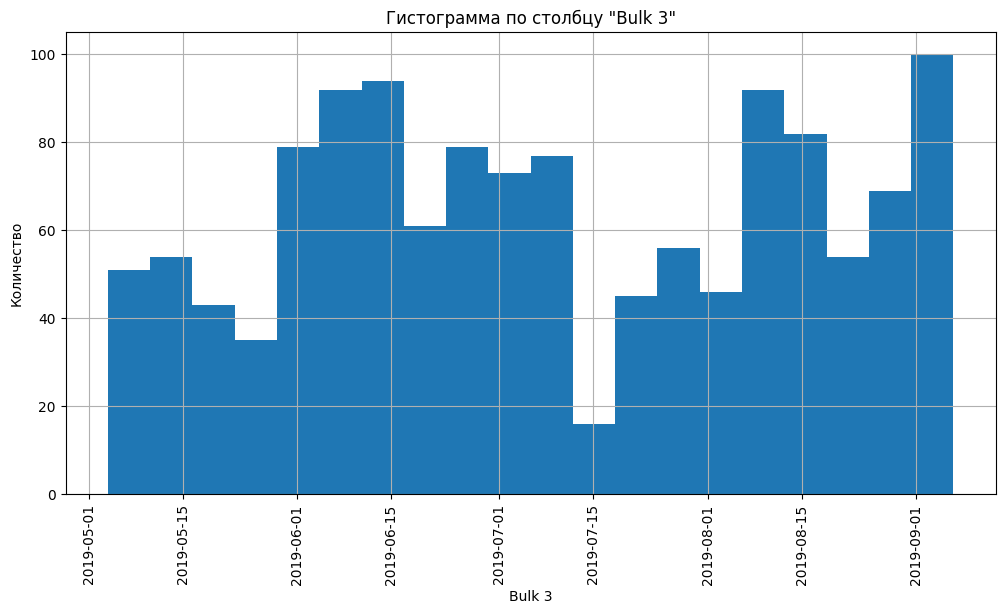

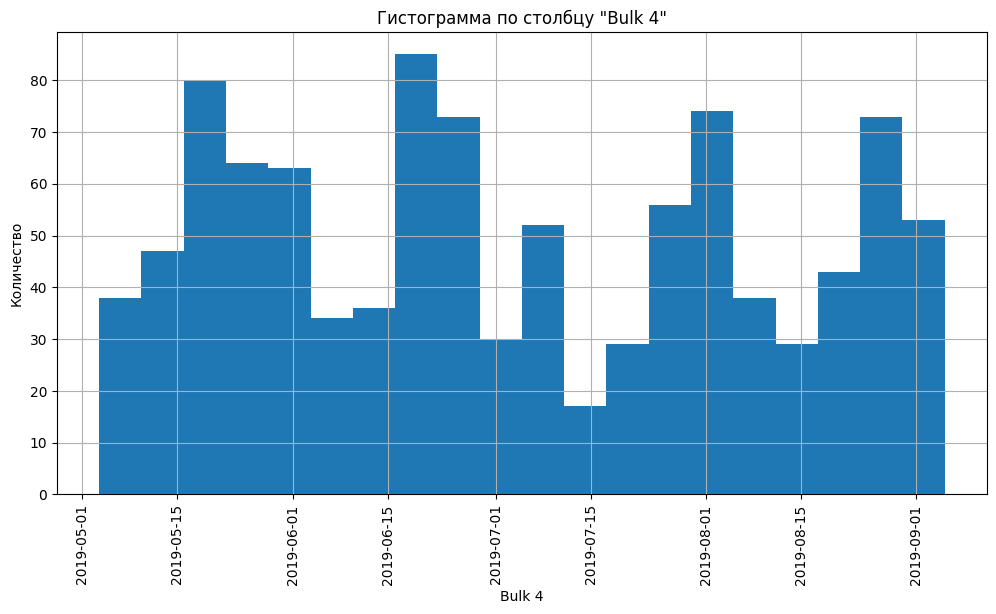

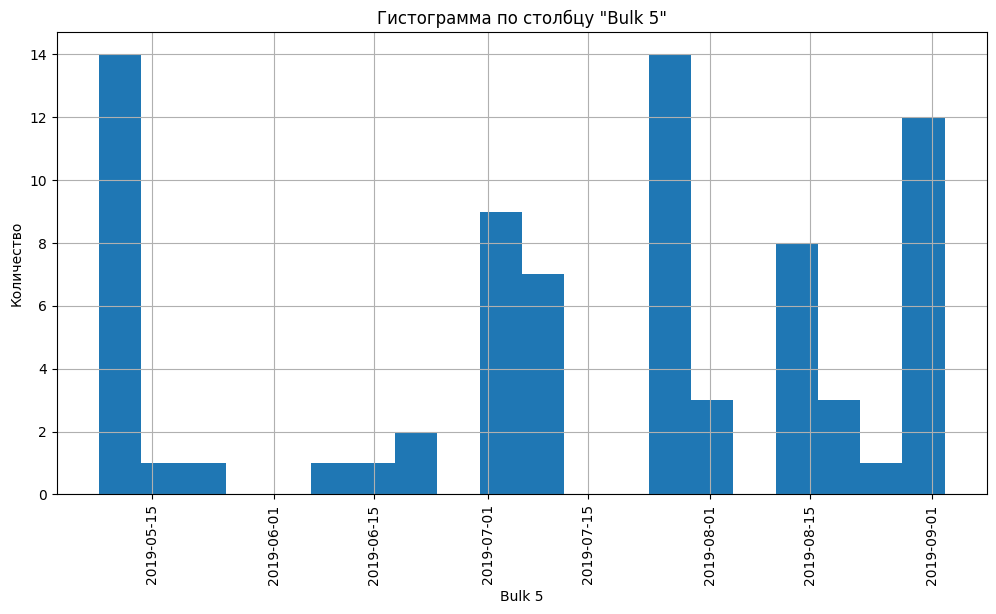

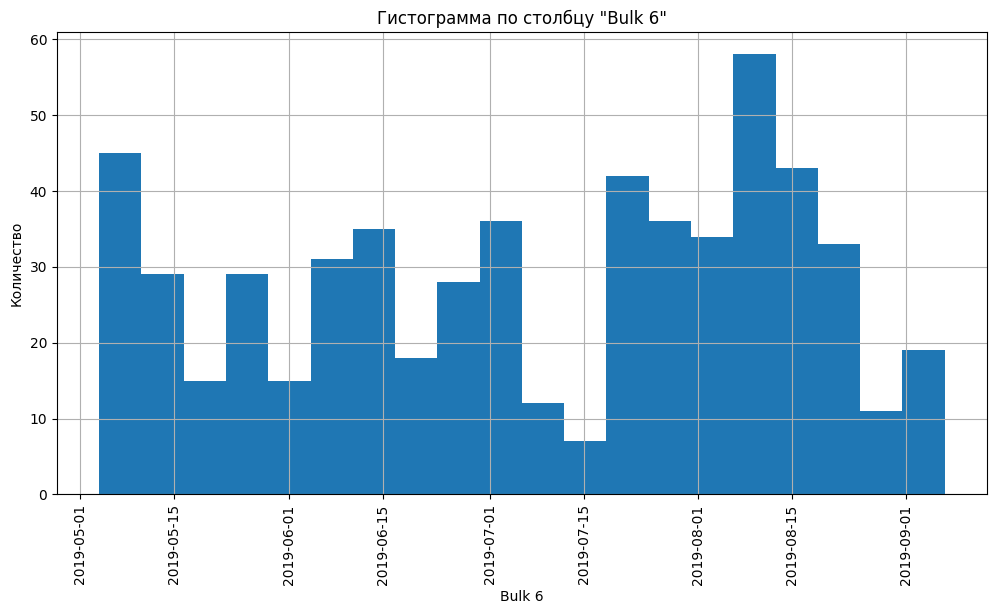

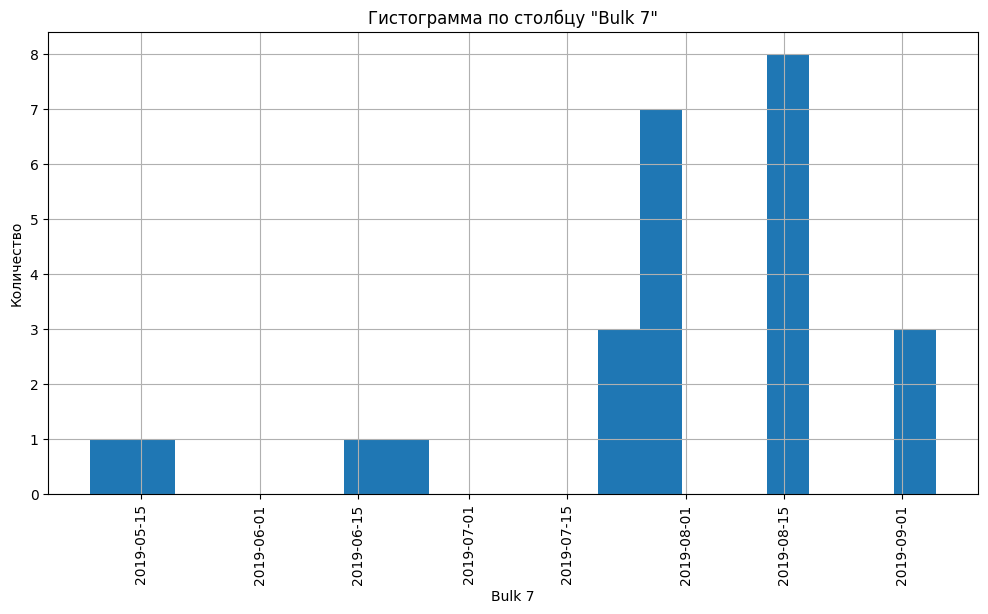

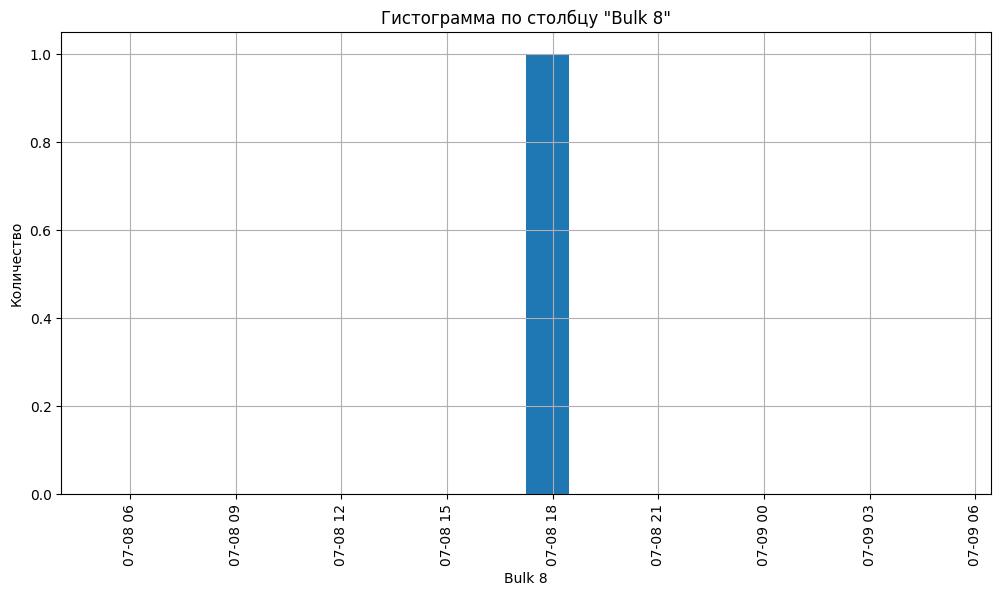

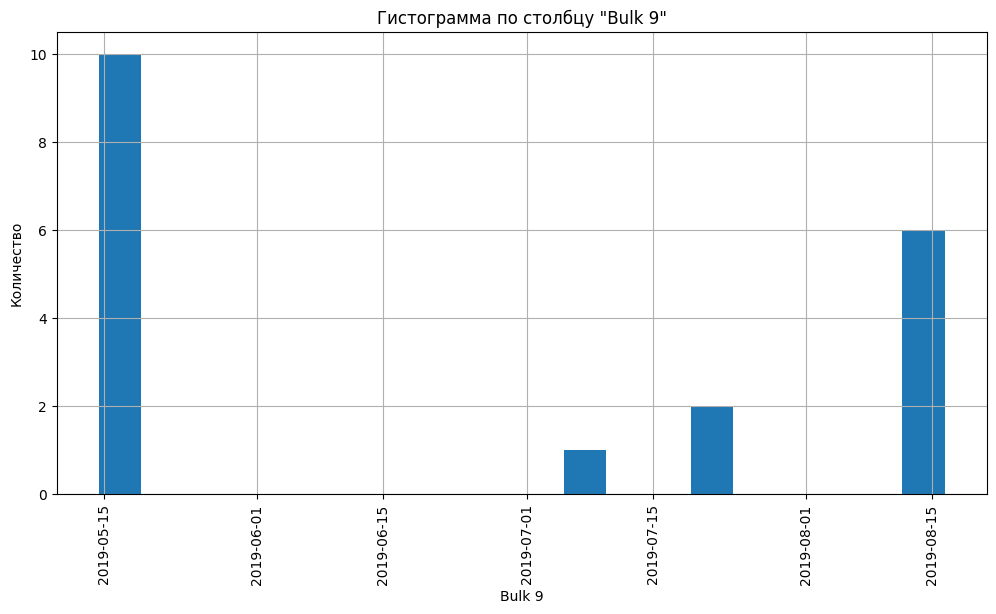

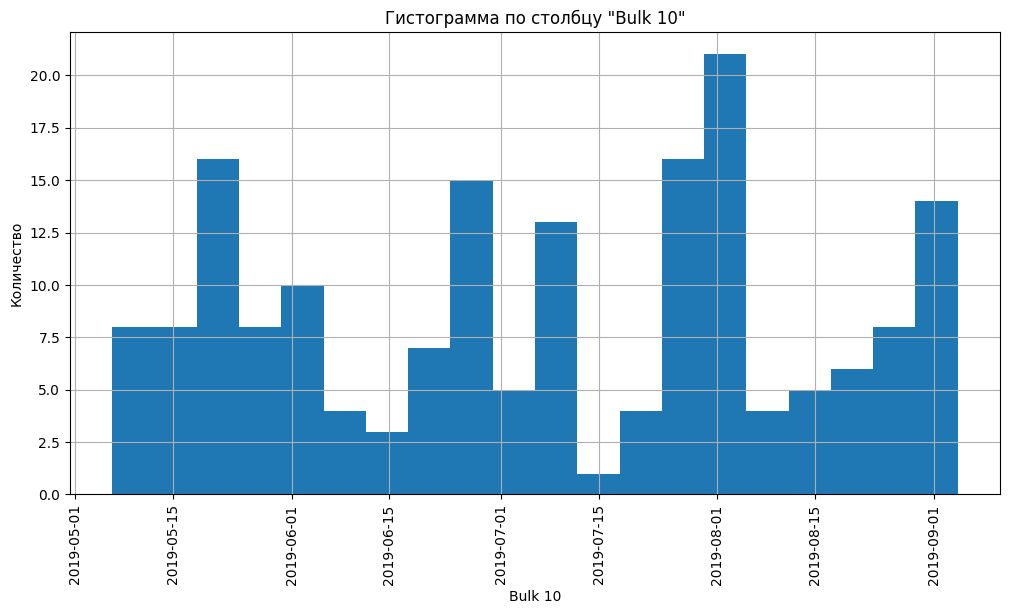

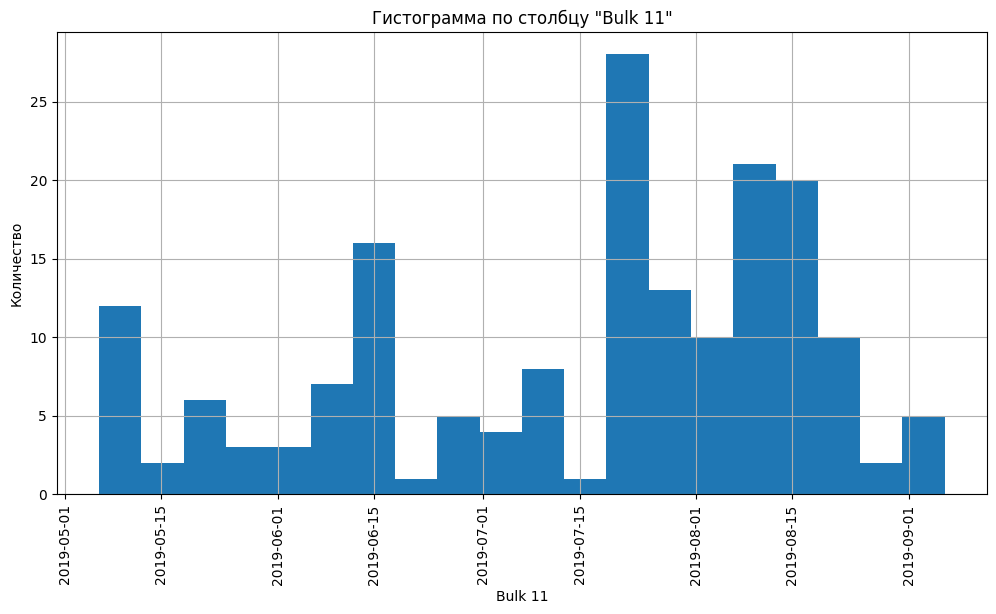

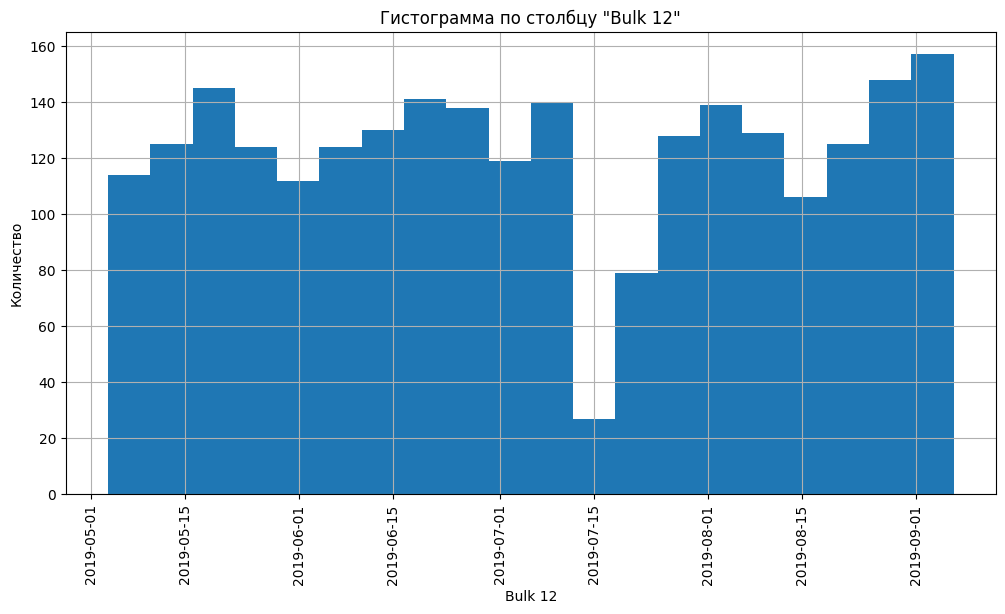

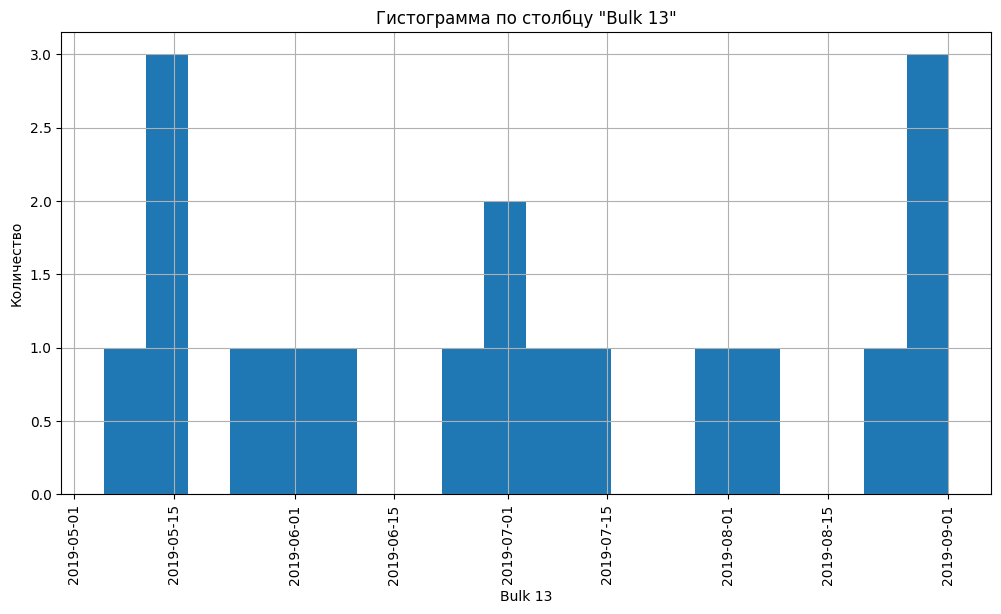

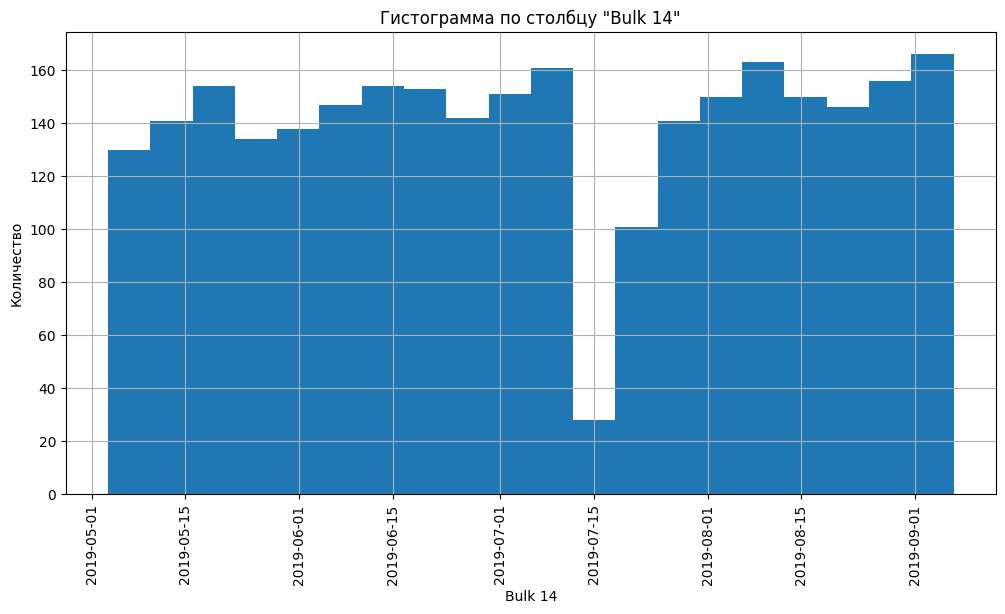

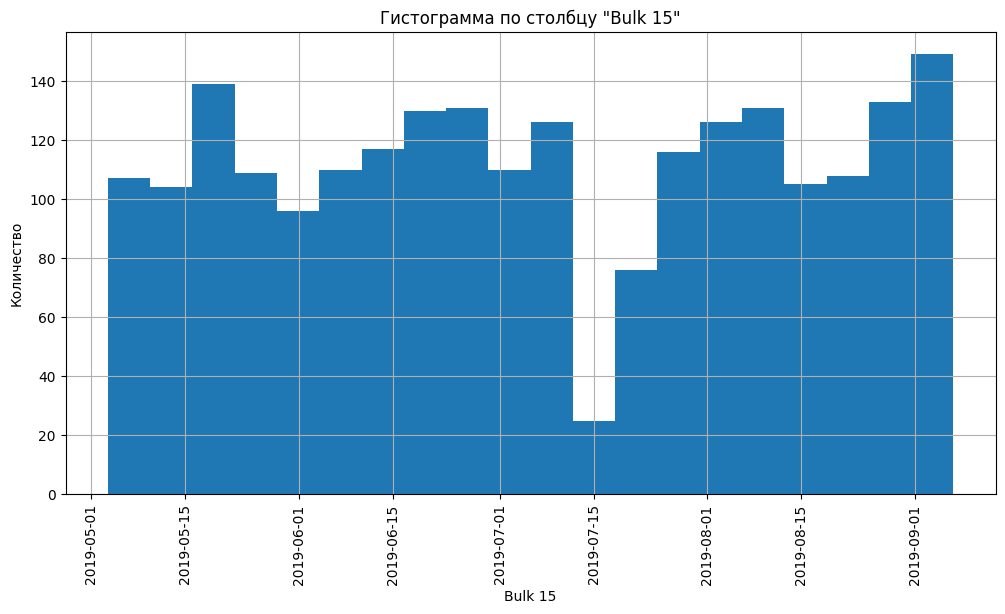

In [164]:
df_hist(df_data_bulk_time)

In [165]:
df_data_bulk_time = df_data_bulk_time.copy()
cols = df_data_bulk_time.columns[1:]
df_data_bulk_time['max_diff_bulk'] = df_data_bulk_time[cols].max(axis=1) \
    								- df_data_bulk_time[cols].min(axis=1)
df_data_bulk_time['min_time'] = df_data_bulk_time[cols].min(axis=1)
df_data_bulk_time[df_data_bulk_time['max_diff_bulk'] > pd.Timedelta(hours=2)]

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15,max_diff_bulk,min_time
1818,1880,NaT,NaT,2019-07-12 10:21:30,NaT,NaT,2019-07-12 10:13:21,NaT,NaT,NaT,NaT,2019-07-12 09:06:13,2019-07-12 08:06:14,NaT,2019-07-12 07:52:20,2019-07-12 07:45:54,0 days 02:35:36,2019-07-12 07:45:54
1819,1881,NaT,NaT,2019-07-12 13:55:14,NaT,NaT,2019-07-12 13:48:37,NaT,NaT,NaT,NaT,2019-07-12 13:43:25,2019-07-12 13:28:04,NaT,2019-07-12 10:56:50,2019-07-12 10:42:42,0 days 03:12:32,2019-07-12 10:42:42
1895,1958,NaT,NaT,2019-07-21 14:44:03,NaT,NaT,2019-07-21 14:39:15,NaT,NaT,NaT,NaT,NaT,2019-07-21 14:31:46,NaT,2019-07-21 14:27:11,2019-07-21 10:56:00,0 days 03:48:03,2019-07-21 10:56:00
2859,2965,NaT,NaT,NaT,2019-08-28 05:41:34,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-08-28 05:32:52,NaT,2019-08-28 05:26:34,2019-08-28 03:40:56,0 days 02:00:38,2019-08-28 03:40:56


In [166]:
df_data_bulk_time.rename(columns=lambda x: x.replace('Bulk ', 'bulk_time_'), inplace=True)
for col in df_data_bulk_time.columns[1:-2]:
    df_data_bulk_time[col] = df_data_bulk_time[col] - df_data_bulk_time['min_time']
    df_data_bulk_time[col] = df_data_bulk_time[col].dt.total_seconds()/60
df_data_bulk_time.drop(columns=['min_time'], inplace=True)
df_data_bulk_time['max_diff_bulk'] = df_data_bulk_time['max_diff_bulk'].dt.total_seconds()/60

In [167]:
df_data_bulk_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   key            3129 non-null   int64  
 1   bulk_time_1    252 non-null    float64
 2   bulk_time_2    22 non-null     float64
 3   bulk_time_3    1298 non-null   float64
 4   bulk_time_4    1014 non-null   float64
 5   bulk_time_5    77 non-null     float64
 6   bulk_time_6    576 non-null    float64
 7   bulk_time_7    25 non-null     float64
 8   bulk_time_8    1 non-null      float64
 9   bulk_time_9    19 non-null     float64
 10  bulk_time_10   176 non-null    float64
 11  bulk_time_11   177 non-null    float64
 12  bulk_time_12   2450 non-null   float64
 13  bulk_time_13   18 non-null     float64
 14  bulk_time_14   2806 non-null   float64
 15  bulk_time_15   2248 non-null   float64
 16  max_diff_bulk  3129 non-null   float64
dtypes: float64(16), int64(1)
memory usage: 415.7 KB


In [168]:
df_data_bulk_time.head(5)

,key,bulk_time_1,bulk_time_2,bulk_time_3,bulk_time_4,bulk_time_5,bulk_time_6,bulk_time_7,bulk_time_8,bulk_time_9,bulk_time_10,bulk_time_11,bulk_time_12,bulk_time_13,bulk_time_14,bulk_time_15,max_diff_bulk
0,1,NaN,NaN,NaN,18.083333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.800000,NaN,4.116667,0.000000,18.083333
1,2,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.666667,NaN,11.783333,7.816667,16.666667
2,3,NaN,NaN,NaN,16.383333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.950000,NaN,4.750000,0.000000,16.383333
3,4,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.633333,NaN,7.816667,3.233333,14.633333
4,5,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,3.416667,0.000000,3.416667


#### Промежуточный вывод

Для ключей 1880, 1881, 1958, 2965 добавление материалов имеет разницу до 4 часов, но не более. Данные выглядят адекватно.

Время засыпким материала приведено к количеству минут после засыпки первого материала

### Таблица steel.data_gas

Проведите исследовательский анализ данных: проверьте наличие пропусков и аномалий, изучите распределение признаков.

In [169]:
query(txt="SELECT * FROM data_gas \
            LIMIT 5")

,key,Газ 1
0,1,29.749986
1,2,12.555561
2,3,28.554793
3,4,18.841219
4,5,5.413692


In [170]:
df_data_gas = query(txt="SELECT * FROM data_gas")

In [171]:
df_data_gas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3239 entries, 0 to 3238
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3239 non-null   int64  
 1   Газ 1   3239 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 50.7 KB


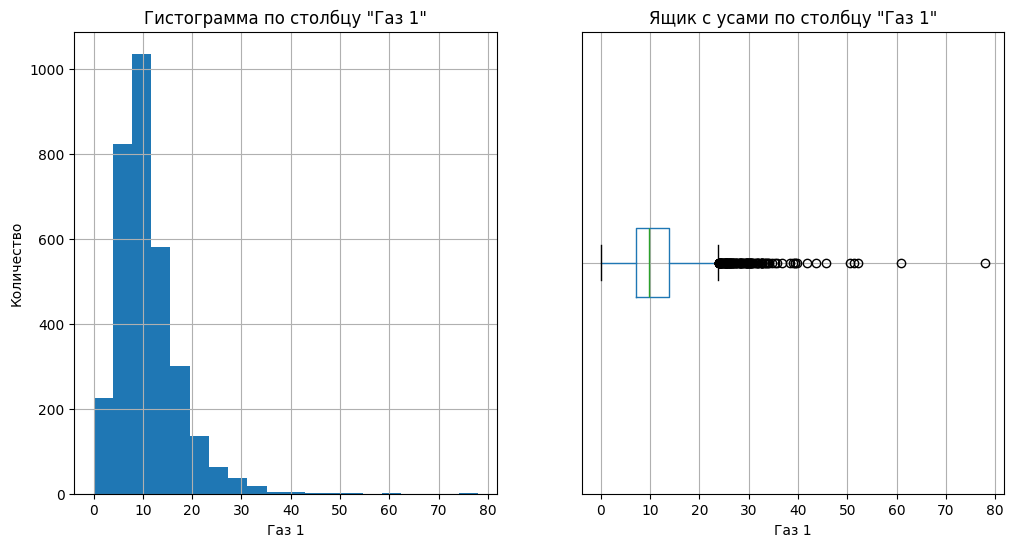

In [172]:
df_hist(df_data_gas)

In [173]:
numeric_cols = df_data_gas.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    stat, p = shapiro(df_data_gas[col])
    print(f"{col}: W = {stat:.4f}, p = {p:.4f}")

key: W = 0.9550, p = 0.0000
Газ 1: W = 0.8868, p = 0.0000


p-value ≤ 0.05 → данные статистически значимо отличаются от нормального распределения

#### Промежуточный вывод

Данные не выглядят нормально распределенными. Больше всего похоже на распределение Пуассона

### Таблица steel.data_temp

Проведите исследовательский анализ данных: проверьте наличие пропусков и аномалий, изучите распределения признаков.

Целевой признак — последняя температура партии. Начальную температуру партии можно использовать как входной признак. Любые другие промежуточные значения температуры приведут к утечке целевого признака, их нельзя использовать как входные.

При агрегировании наблюдений используйте только ключи, у которых как минимум два наблюдения: первый и последний замеры температуры.

Заказчик предупредил, что значения температуры ниже 1500 градусов — аномальные.

In [174]:
query(txt="SELECT * FROM data_temp \
            LIMIT 20")

,key,Время замера,Температура
0,1,2019-05-03 11:02:04,1571.0
1,1,2019-05-03 11:07:18,1604.0
2,1,2019-05-03 11:11:34,1618.0
3,1,2019-05-03 11:18:04,1601.0
4,1,2019-05-03 11:25:59,1606.0
5,1,2019-05-03 11:30:38,1613.0
6,2,2019-05-03 11:34:04,1581.0
7,2,2019-05-03 11:38:40,1577.0
8,2,2019-05-03 11:46:09,1589.0
9,2,2019-05-03 11:49:38,1604.0


In [175]:
query(txt="""
      WITH ranked AS (
          SELECT 
              key,
              "Время замера" AS time,
              "Температура" AS temp,
              ROW_NUMBER() OVER (PARTITION BY key ORDER BY "Время замера" ASC)  AS rn_asc,
              ROW_NUMBER() OVER (PARTITION BY key ORDER BY "Время замера" DESC) AS rn_desc
          FROM data_temp
      )
      SELECT 
          key,
          MAX(CASE WHEN rn_asc = 1 THEN temp END) AS earliest_temp,
          MAX(CASE WHEN rn_desc = 1 THEN temp END) AS target_temp,
          MAX(CASE WHEN rn_asc = 1 THEN time END) AS early_time,
          MAX(CASE WHEN rn_desc = 1 THEN time END) AS late_time
      FROM ranked
      GROUP BY key
      HAVING early_time != late_time
      LIMIT 10
      """)

,key,earliest_temp,target_temp,early_time,late_time
0,1,1571.0,1613.0,2019-05-03 11:02:04,2019-05-03 11:30:38
1,2,1581.0,1602.0,2019-05-03 11:34:04,2019-05-03 11:55:09
2,3,1596.0,1599.0,2019-05-03 12:06:44,2019-05-03 12:35:57
3,4,1601.0,1625.0,2019-05-03 12:39:27,2019-05-03 12:59:47
4,5,1576.0,1602.0,2019-05-03 13:11:03,2019-05-03 13:36:39
5,6,1543.0,1596.0,2019-05-03 13:46:41,2019-05-03 14:11:38
6,7,1586.0,1599.0,2019-05-03 14:16:36,2019-05-03 14:45:40
7,8,1577.0,1598.0,2019-05-03 14:53:46,2019-05-03 15:20:41
8,9,1587.0,1592.0,2019-05-03 15:36:33,2019-05-03 16:06:44
9,10,1574.0,1593.0,2019-05-03 16:13:59,2019-05-03 16:39:50


In [176]:
df_data_temp = query(txt="""
      WITH ranked AS (
          SELECT 
              key,
              "Время замера" AS time,
              "Температура" AS temp,
              ROW_NUMBER() OVER (PARTITION BY key ORDER BY "Время замера" ASC)  AS rn_asc,
              ROW_NUMBER() OVER (PARTITION BY key ORDER BY "Время замера" DESC) AS rn_desc
          FROM data_temp
      )
      SELECT 
          key,
          MAX(CASE WHEN rn_asc = 1 THEN temp END) AS early_temp,
          MAX(CASE WHEN rn_desc = 1 THEN temp END) AS target_temp,
          MAX(CASE WHEN rn_asc = 1 THEN time END) AS early_time,
          MAX(CASE WHEN rn_desc = 1 THEN time END) AS late_time
      FROM ranked
      GROUP BY key
      HAVING early_time != late_time
      AND target_temp >= 1500
      AND early_temp >= 1400
      """)

In [177]:
df_data_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2475 entries, 0 to 2474
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   key          2475 non-null   int64 
 1   early_temp   2475 non-null   object
 2   target_temp  2475 non-null   object
 3   early_time   2475 non-null   object
 4   late_time    2475 non-null   object
dtypes: int64(1), object(4)
memory usage: 96.8+ KB


In [178]:
df_data_temp['early_temp'] = pd.to_numeric(df_data_temp['early_temp'])
df_data_temp['target_temp'] = pd.to_numeric(df_data_temp['target_temp'])
df_data_temp['early_time'] = pd.to_datetime(df_data_temp['early_time'])
df_data_temp['late_time'] = pd.to_datetime(df_data_temp['late_time'])

In [179]:
df_data_temp = df_data_temp[df_data_temp['early_temp'] >= 1400]

In [180]:
df_data_temp['duration_temp'] = (df_data_temp['late_time'] - df_data_temp['early_time']).dt.total_seconds()/60
df_data_temp.drop(columns=['late_time','early_time'], inplace=True)

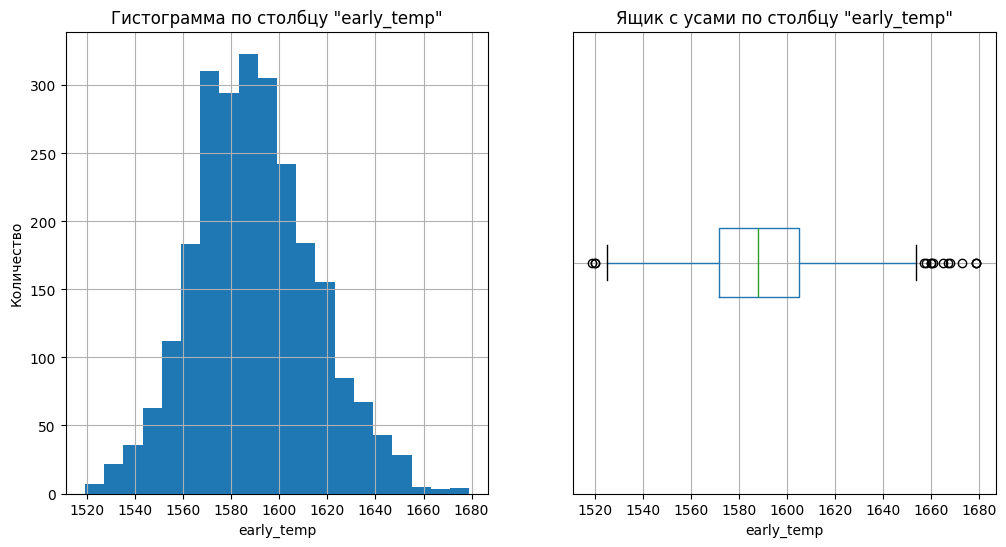

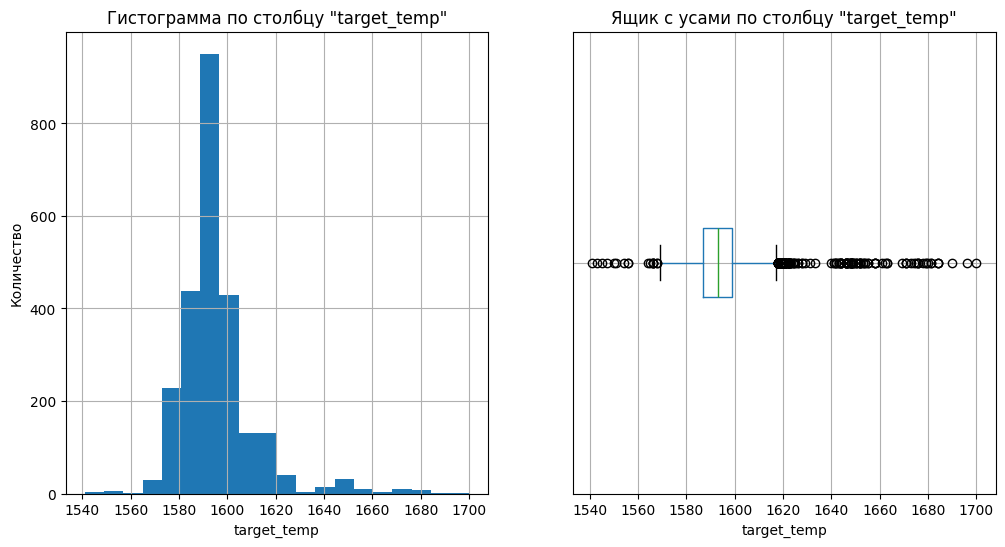

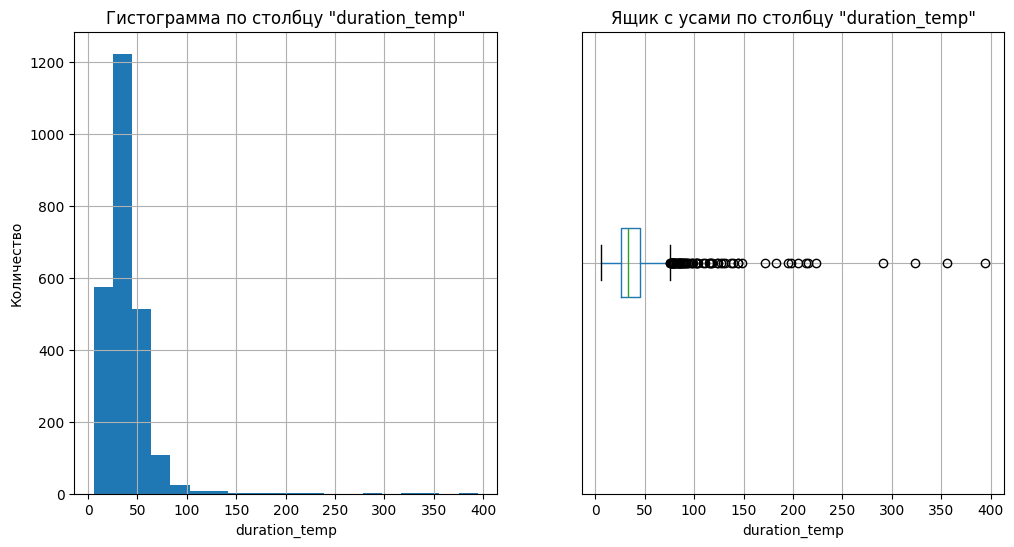

In [181]:
df_hist(df_data_temp)

In [182]:
numeric_cols = df_data_temp.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    stat, p = shapiro(df_data_temp[col])
    print(f"{col}: W = {stat:.4f}, p = {p:.4f}")

key: W = 0.9552, p = 0.0000
early_temp: W = 0.9949, p = 0.0000
target_temp: W = 0.8177, p = 0.0000
duration_temp: W = 0.6564, p = 0.0000


p-value ≤ 0.05 → данные статистически значимо отличаются от нормального распределения

#### Промежуточный вывод

Согласно полученным данным видно, что температуры рапределены не нормально. Больше всего похоже на распределение Пуассона. При этом имеется снижение количество замеров в районе 15 июля 2019 года

### Таблица steel.data_wire

Обработайте пропуски. Пропуск означает, что материал не добавляли в эту партию.

In [183]:
query(txt="SELECT * FROM data_wire \
            LIMIT 5")

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,60.059998,None,None,None,None,None,None,None,None
1,2,96.052315,None,None,None,None,None,None,None,None
2,3,91.160157,None,None,None,None,None,None,None,None
3,4,89.063515,None,None,None,None,None,None,None,None
4,5,89.238236,9.11456,None,None,None,None,None,None,None


In [184]:
df_data_wire = query(txt="SELECT * FROM data_wire")

In [185]:
for col in df_data_wire.columns:
	df_data_wire[col] = pd.to_numeric(df_data_wire[col])

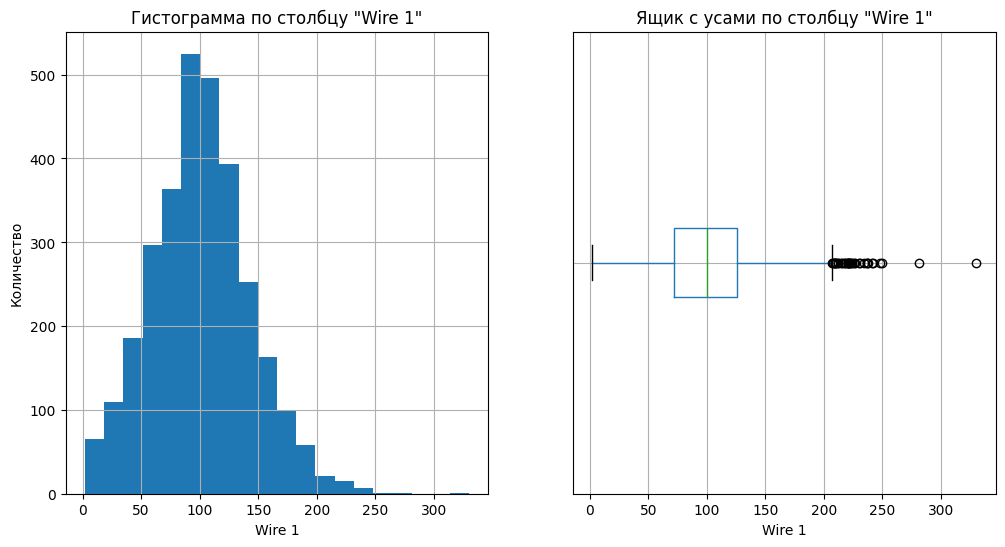

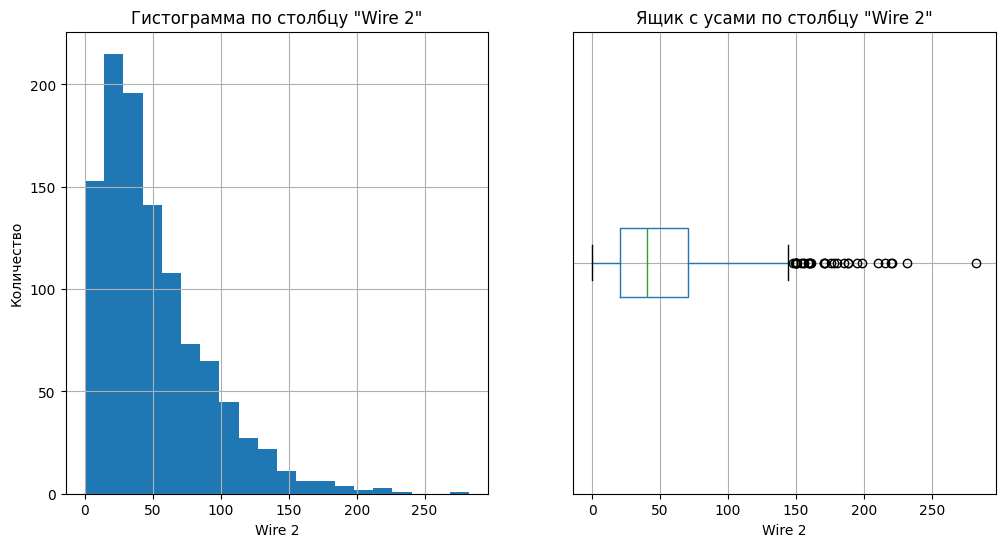

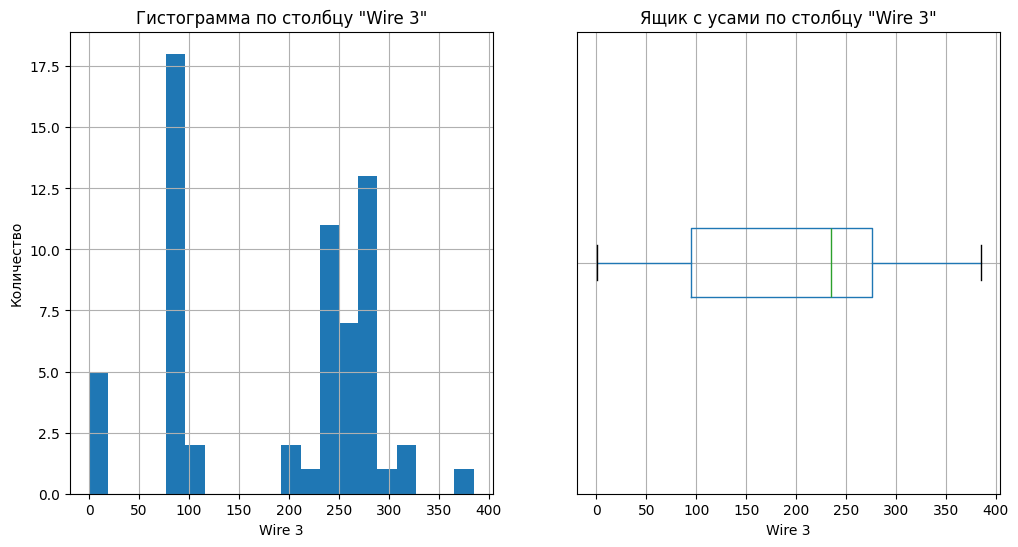

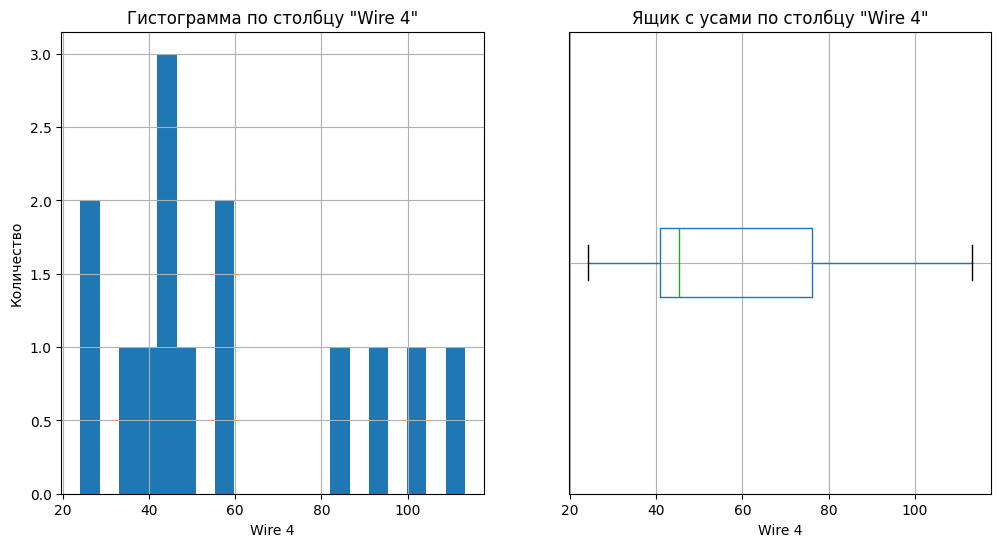

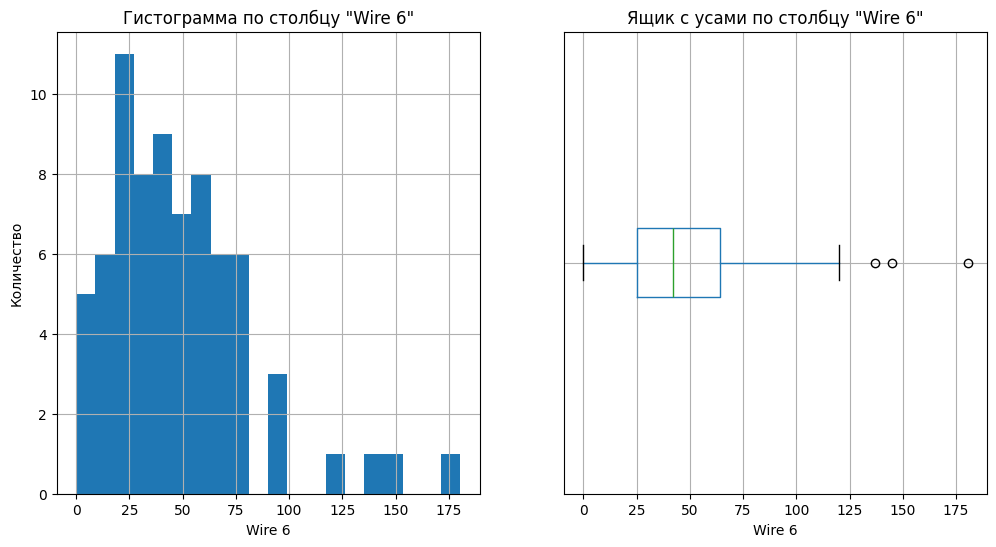

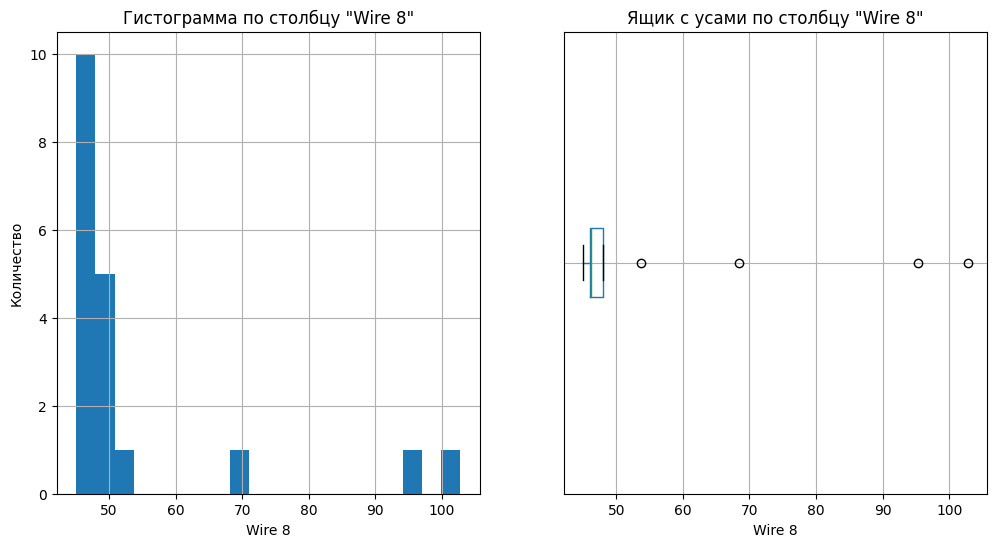

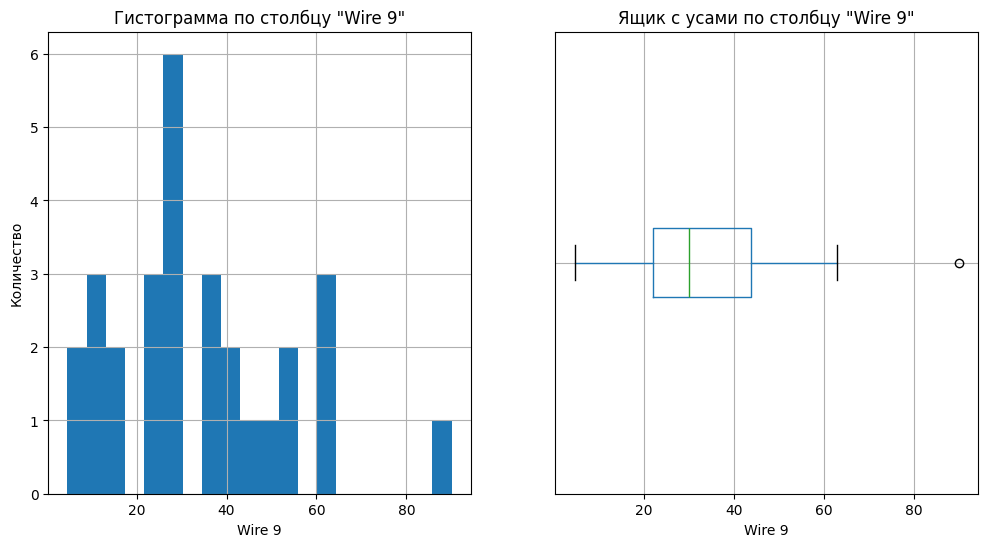

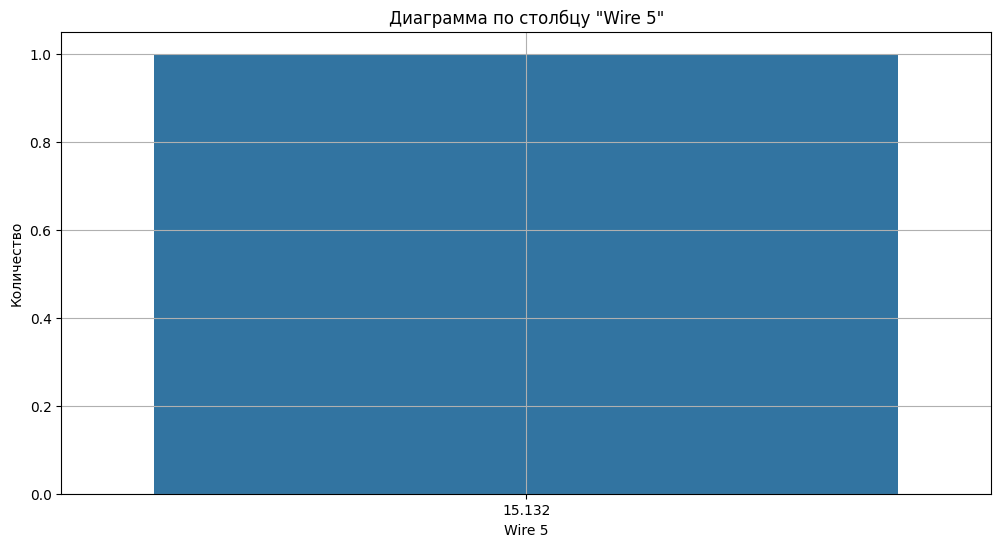

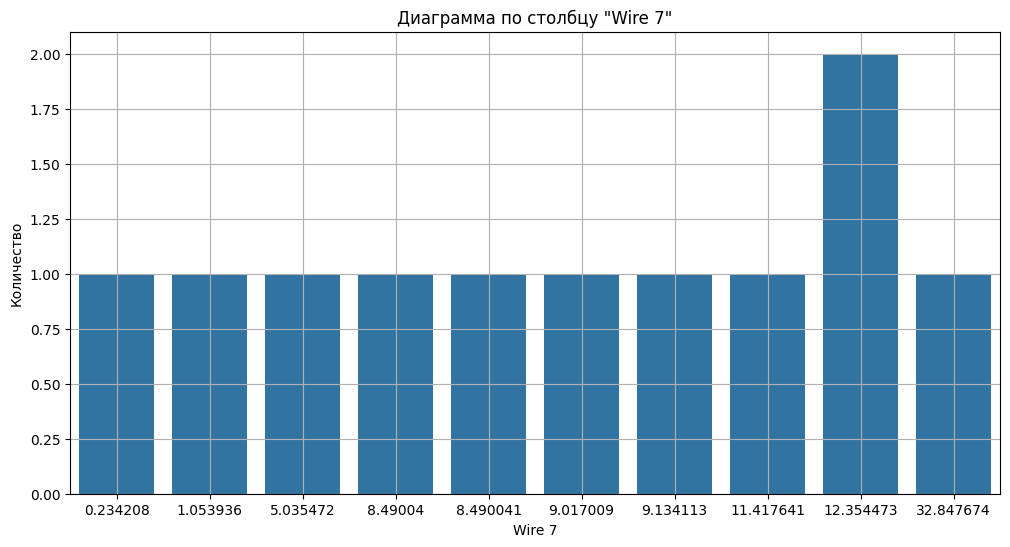

In [186]:
df_hist(df_data_wire)

In [187]:
df_data_wire.fillna(0, inplace=True)

#### Промежуточный вывод

Данные выглядят адекватно. Данные приведены к числовому типу

### Таблица steel.data_wire_time

Проведите исследовательский анализ данных: проверьте наличие пропусков и аномалий, изучите распределение признаков.

Проверьте данные на адекватность: например, убедитесь, что подача материала не измеряется сутками. Обратите внимание: перед вами не стоит задача временных рядов.

In [188]:
query(txt="SELECT * FROM data_wire_time \
            LIMIT 5")

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,2019-05-03 11:06:19,None,None,None,None,None,None,None,None
1,2,2019-05-03 11:36:50,None,None,None,None,None,None,None,None
2,3,2019-05-03 12:11:46,None,None,None,None,None,None,None,None
3,4,2019-05-03 12:43:22,None,None,None,None,None,None,None,None
4,5,2019-05-03 13:20:44,2019-05-03 13:15:34,None,None,None,None,None,None,None


In [189]:
df_data_wire_time = query(txt="SELECT * FROM data_wire_time")

In [190]:
for col in df_data_wire_time.drop(columns=['key']).columns:
	df_data_wire_time[col] = pd.to_datetime(df_data_wire_time[col], errors='coerce')

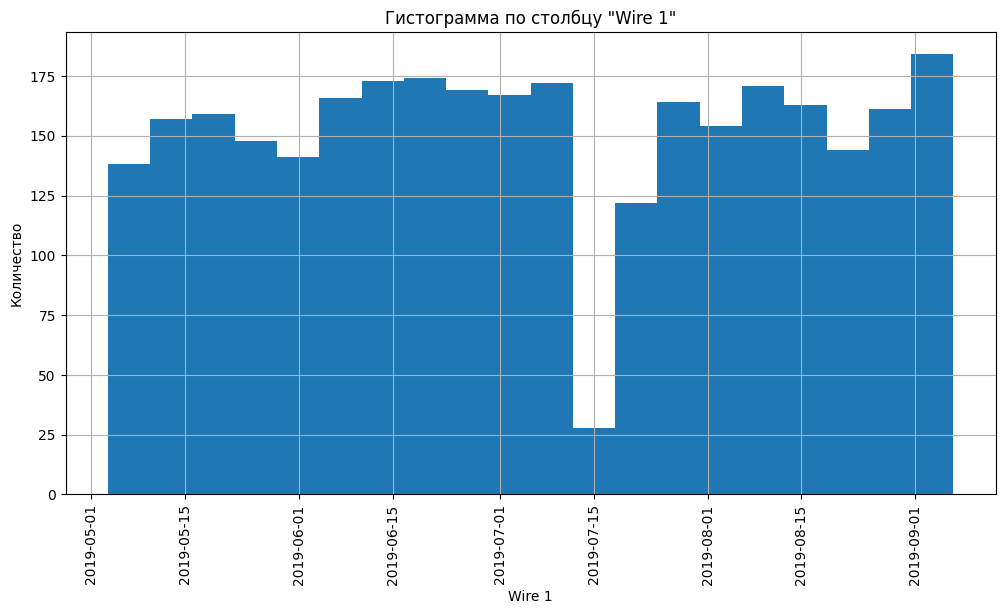

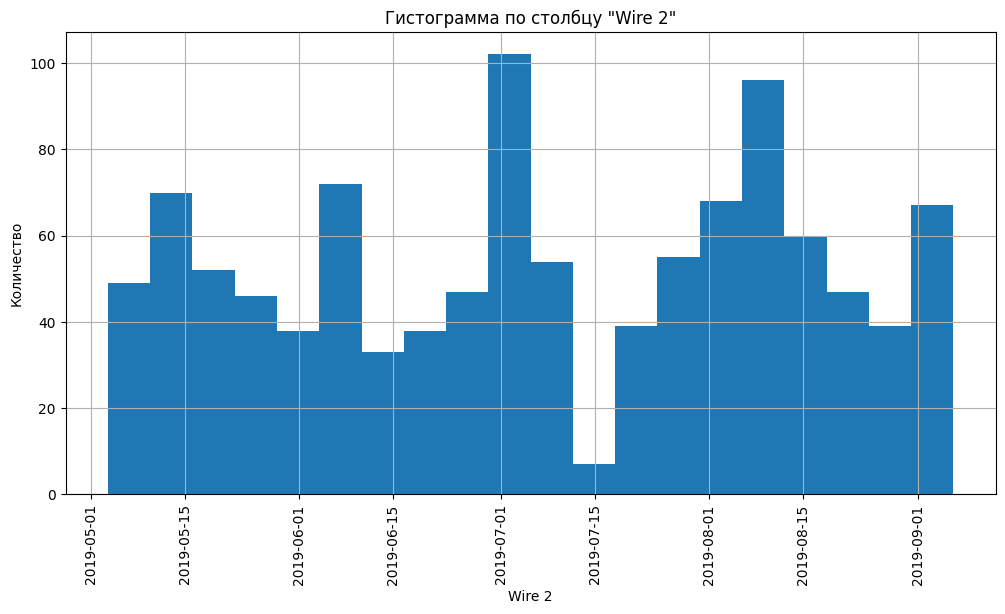

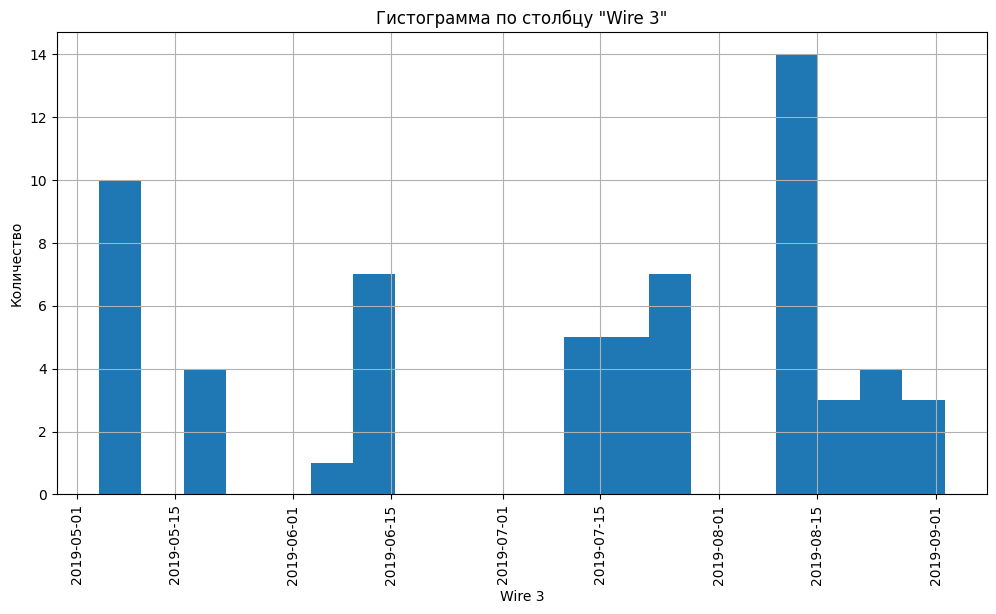

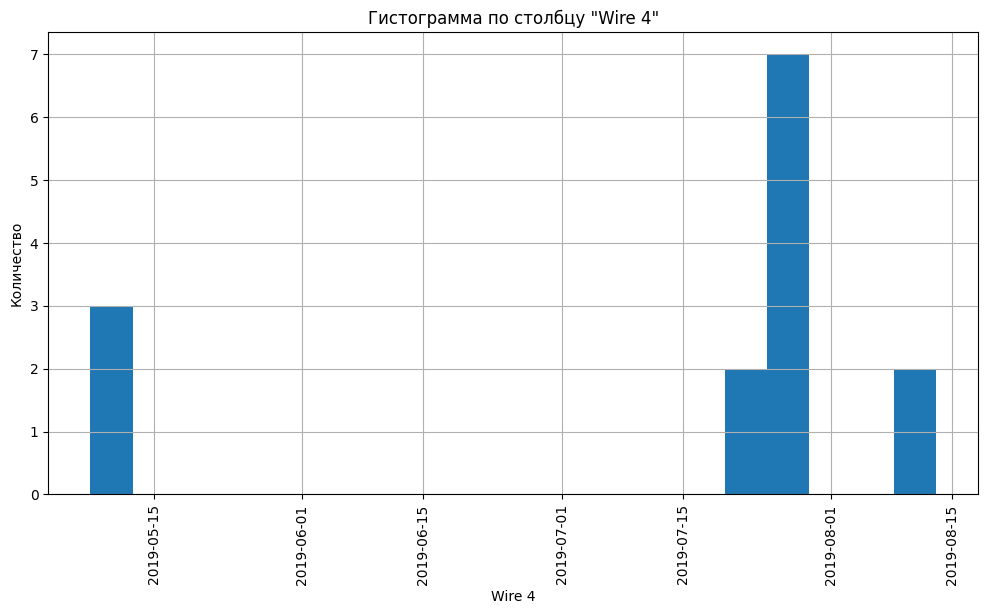

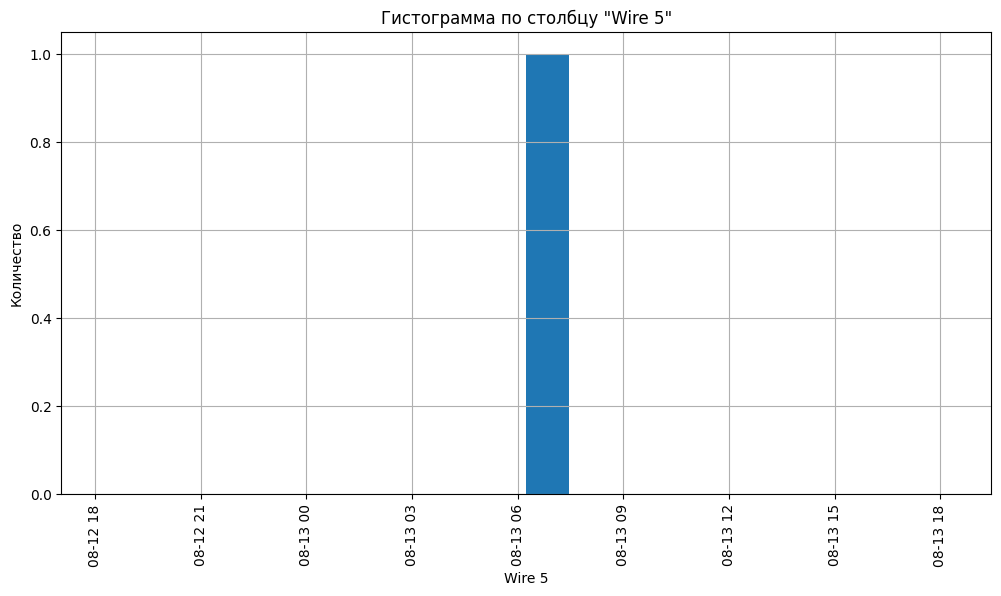

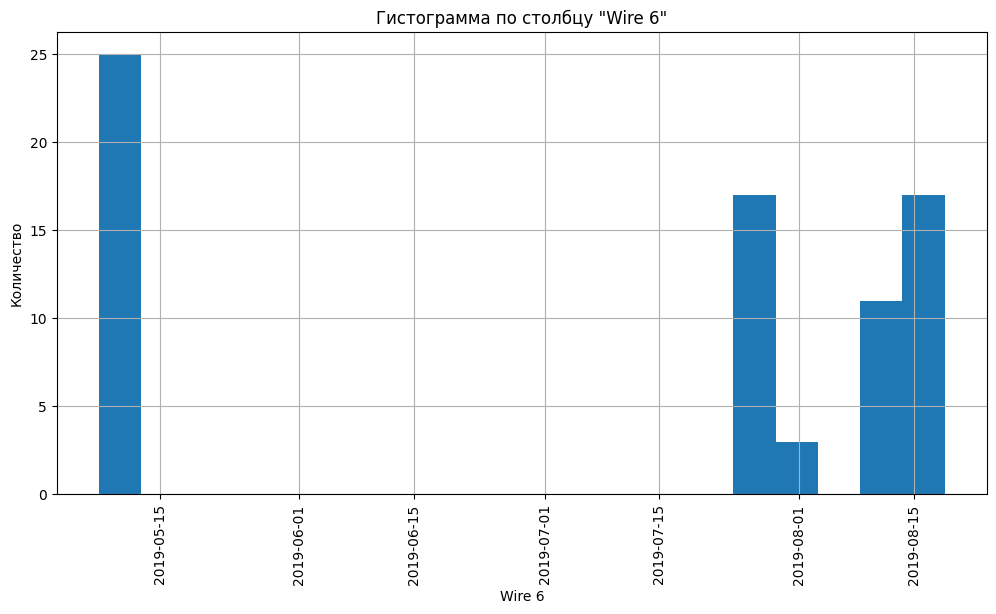

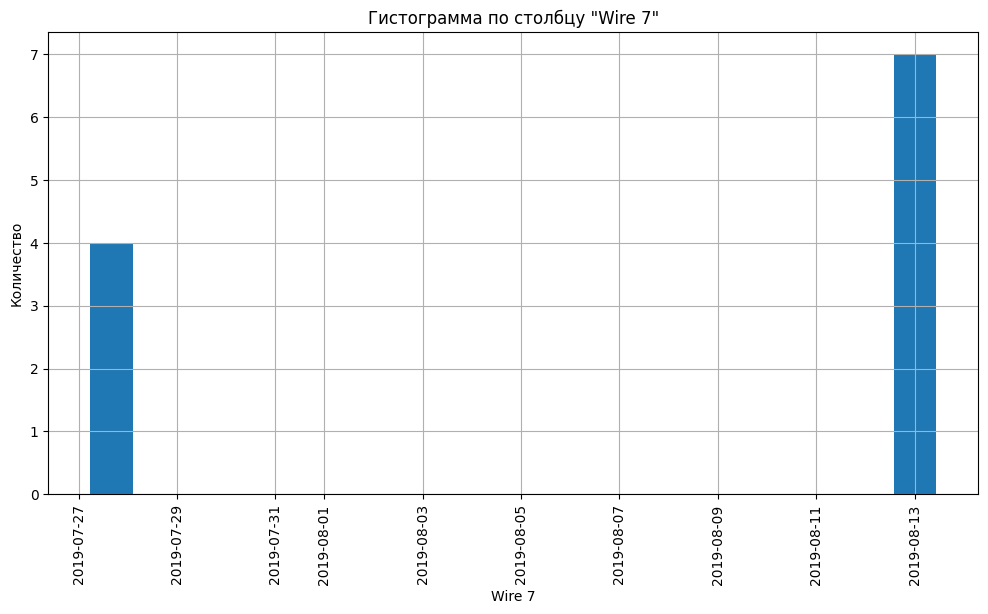

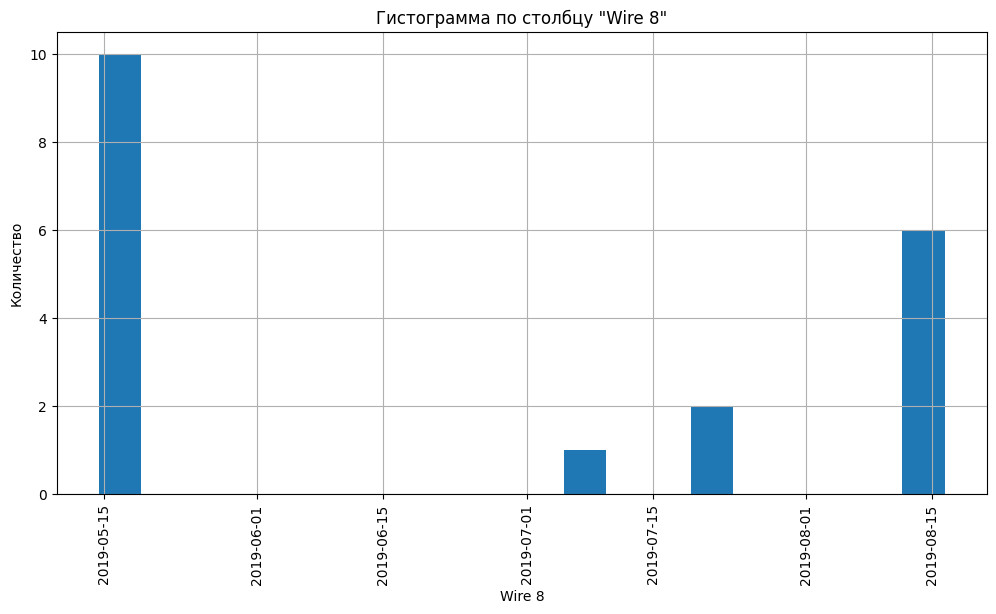

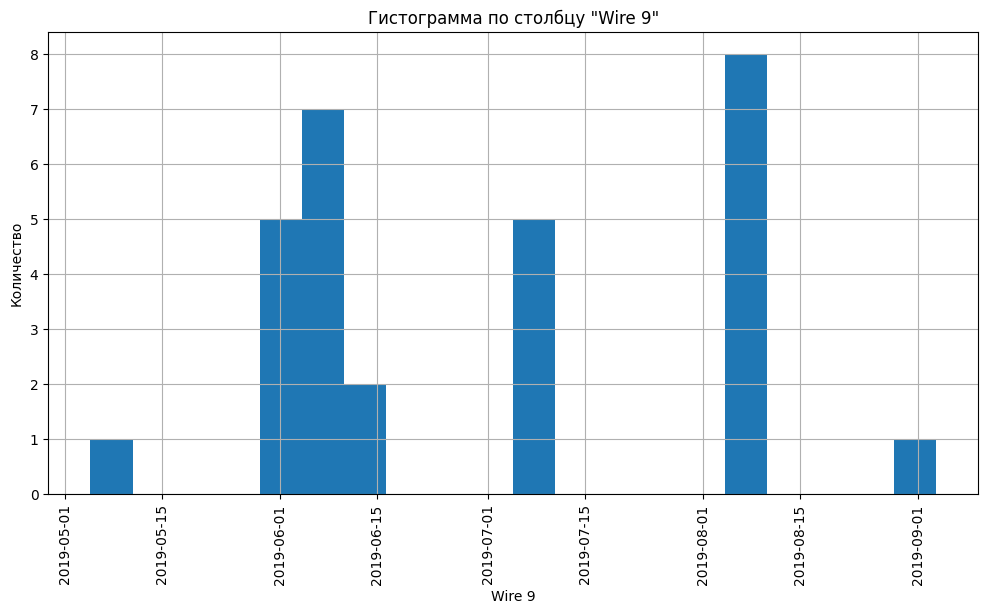

In [191]:
df_hist(df_data_wire_time)

In [192]:
cols = df_data_wire_time.columns[1:]
df_data_wire_time['max_diff_wire'] = df_data_wire_time[cols].max(axis=1) \
    								- df_data_wire_time[cols].min(axis=1)
df_data_wire_time['min_time'] = df_data_wire_time[cols].min(axis=1)
df_data_wire_time[df_data_wire_time['max_diff_wire'] > pd.Timedelta(hours=1)]

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9,max_diff_wire,min_time
2010,2108,2019-07-27 15:15:04,NaT,2019-07-27 14:05:34,2019-07-27 13:57:58,NaT,2019-07-27 13:48:37,2019-07-27 13:43:32,NaT,NaT,0 days 01:31:32,2019-07-27 13:43:32
2012,2110,2019-07-27 20:50:19,NaT,2019-07-27 20:02:21,2019-07-27 19:41:36,NaT,2019-07-27 19:15:43,2019-07-27 19:11:22,NaT,NaT,0 days 01:38:57,2019-07-27 19:11:22
2439,2566,2019-08-13 04:15:39,NaT,2019-08-13 03:21:46,2019-08-13 03:16:45,NaT,2019-08-13 03:04:56,2019-08-13 02:52:06,NaT,NaT,0 days 01:23:33,2019-08-13 02:52:06


In [193]:
df_data_wire_time.rename(columns=lambda x: x.replace('Wire ', 'wire_time_'), inplace=True)
for col in df_data_wire_time.columns[1:10]:
    df_data_wire_time[col] = df_data_wire_time[col] - df_data_wire_time['min_time']
    df_data_wire_time[col] = df_data_wire_time[col].dt.total_seconds()/60
df_data_wire_time.drop(columns=['min_time'], inplace=True)
df_data_wire_time['max_diff_wire'] = df_data_wire_time['max_diff_wire'].dt.total_seconds()/60

In [194]:
df_data_wire_time.head(5)

,key,wire_time_1,wire_time_2,wire_time_3,wire_time_4,wire_time_5,wire_time_6,wire_time_7,wire_time_8,wire_time_9,max_diff_wire
0,1,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
1,2,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
2,3,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
3,4,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
4,5,5.166667,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.166667


#### Промежуточный вывод

Данные выглядят адекватно. Только для трех ключей добавление проволочных материалов превышает 1 час, но не более 2 часов

Время подачи проволоки приведено к количеству минут после подачи первой проволоки

## Подготовка данных

### Объединение таблицы по ключу

Каждой партии должно соответствовать одно наблюдение.

Учтите: во все партии точно добавлялись сыпучие и проволочные материалы, везде была выполнена продувка газом и сплав всегда нагревался.

Заказчик предупредил, что иногда наблюдается асинхронность в заданном времени разных датчиков. Если вы будете выстраивать хронологию процессов для разных партий, то можете столкнуться с тем, что полученная хронология не соответствует хронологии в описании. Не стоит воспринимать это как ошибку.

Проведите исследовательский анализ данных объединённой таблицы и визуализируйте распределение каждого признака, напишите выводы.

Проведите корреляционный анализ.

In [195]:
df_data_arc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3213 entries, 1 to 3241
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   count_usage        3213 non-null   int64  
 1   active_mean_power  3213 non-null   float64
 2   react_mean_power   3213 non-null   float64
 3   mean_power         3213 non-null   float64
 4   total_duration     3213 non-null   int64  
 5   mean_duration      3213 non-null   float64
dtypes: float64(4), int64(2)
memory usage: 175.7 KB


In [196]:
df_data_bulk.rename(columns=lambda x: x.replace('Bulk ', 'bulk_'), inplace=True)
df_data_bulk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   bulk_1   3129 non-null   float64
 2   bulk_2   3129 non-null   float64
 3   bulk_3   3129 non-null   float64
 4   bulk_4   3129 non-null   float64
 5   bulk_5   3129 non-null   float64
 6   bulk_6   3129 non-null   float64
 7   bulk_7   3129 non-null   float64
 8   bulk_8   3129 non-null   float64
 9   bulk_9   3129 non-null   float64
 10  bulk_10  3129 non-null   float64
 11  bulk_11  3129 non-null   float64
 12  bulk_12  3129 non-null   float64
 13  bulk_13  3129 non-null   float64
 14  bulk_14  3129 non-null   float64
 15  bulk_15  3129 non-null   float64
dtypes: float64(15), int64(1)
memory usage: 391.3 KB


In [197]:
df_data_bulk_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   key            3129 non-null   int64  
 1   bulk_time_1    252 non-null    float64
 2   bulk_time_2    22 non-null     float64
 3   bulk_time_3    1298 non-null   float64
 4   bulk_time_4    1014 non-null   float64
 5   bulk_time_5    77 non-null     float64
 6   bulk_time_6    576 non-null    float64
 7   bulk_time_7    25 non-null     float64
 8   bulk_time_8    1 non-null      float64
 9   bulk_time_9    19 non-null     float64
 10  bulk_time_10   176 non-null    float64
 11  bulk_time_11   177 non-null    float64
 12  bulk_time_12   2450 non-null   float64
 13  bulk_time_13   18 non-null     float64
 14  bulk_time_14   2806 non-null   float64
 15  bulk_time_15   2248 non-null   float64
 16  max_diff_bulk  3129 non-null   float64
dtypes: float64(16), int64(1)
memory usage: 415.7 KB


In [198]:
df_data_gas.rename(columns=lambda x: x.replace('Газ ', 'gas_'), inplace=True)
df_data_gas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3239 entries, 0 to 3238
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3239 non-null   int64  
 1   gas_1   3239 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 50.7 KB


In [199]:
df_data_temp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2471 entries, 0 to 2474
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   key            2471 non-null   int64  
 1   early_temp     2471 non-null   float64
 2   target_temp    2471 non-null   float64
 3   duration_temp  2471 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 96.5 KB


In [200]:
df_data_wire.rename(columns=lambda x: x.replace('Wire ', 'wire_'), inplace=True)
df_data_wire.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3081 non-null   int64  
 1   wire_1  3081 non-null   float64
 2   wire_2  3081 non-null   float64
 3   wire_3  3081 non-null   float64
 4   wire_4  3081 non-null   float64
 5   wire_5  3081 non-null   float64
 6   wire_6  3081 non-null   float64
 7   wire_7  3081 non-null   float64
 8   wire_8  3081 non-null   float64
 9   wire_9  3081 non-null   float64
dtypes: float64(9), int64(1)
memory usage: 240.8 KB


In [201]:
df_data_wire_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   key            3081 non-null   int64  
 1   wire_time_1    3055 non-null   float64
 2   wire_time_2    1079 non-null   float64
 3   wire_time_3    63 non-null     float64
 4   wire_time_4    14 non-null     float64
 5   wire_time_5    1 non-null      float64
 6   wire_time_6    73 non-null     float64
 7   wire_time_7    11 non-null     float64
 8   wire_time_8    19 non-null     float64
 9   wire_time_9    29 non-null     float64
 10  max_diff_wire  3081 non-null   float64
dtypes: float64(10), int64(1)
memory usage: 264.9 KB


#### Объединение таблиц

In [202]:
df_main = df_data_arc.merge(df_data_temp, on='key')
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2470 entries, 0 to 2469
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   key                2470 non-null   int64  
 1   count_usage        2470 non-null   int64  
 2   active_mean_power  2470 non-null   float64
 3   react_mean_power   2470 non-null   float64
 4   mean_power         2470 non-null   float64
 5   total_duration     2470 non-null   int64  
 6   mean_duration      2470 non-null   float64
 7   early_temp         2470 non-null   float64
 8   target_temp        2470 non-null   float64
 9   duration_temp      2470 non-null   float64
dtypes: float64(7), int64(3)
memory usage: 193.1 KB


In [203]:
df_main = df_main.merge(df_data_bulk, on='key', how='left')
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2471 entries, 0 to 2470
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   key                2471 non-null   int64  
 1   count_usage        2471 non-null   int64  
 2   active_mean_power  2471 non-null   float64
 3   react_mean_power   2471 non-null   float64
 4   mean_power         2471 non-null   float64
 5   total_duration     2471 non-null   int64  
 6   mean_duration      2471 non-null   float64
 7   early_temp         2471 non-null   float64
 8   target_temp        2471 non-null   float64
 9   duration_temp      2471 non-null   float64
 10  bulk_1             2402 non-null   float64
 11  bulk_2             2402 non-null   float64
 12  bulk_3             2402 non-null   float64
 13  bulk_4             2402 non-null   float64
 14  bulk_5             2402 non-null   float64
 15  bulk_6             2402 non-null   float64
 16  bulk_7             2402 

In [204]:
df_main = df_main.merge(df_data_bulk_time, on='key', how='left')
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2471 entries, 0 to 2470
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   key                2471 non-null   int64  
 1   count_usage        2471 non-null   int64  
 2   active_mean_power  2471 non-null   float64
 3   react_mean_power   2471 non-null   float64
 4   mean_power         2471 non-null   float64
 5   total_duration     2471 non-null   int64  
 6   mean_duration      2471 non-null   float64
 7   early_temp         2471 non-null   float64
 8   target_temp        2471 non-null   float64
 9   duration_temp      2471 non-null   float64
 10  bulk_1             2402 non-null   float64
 11  bulk_2             2402 non-null   float64
 12  bulk_3             2402 non-null   float64
 13  bulk_4             2402 non-null   float64
 14  bulk_5             2402 non-null   float64
 15  bulk_6             2402 non-null   float64
 16  bulk_7             2402 

In [205]:
df_main = df_main.merge(df_data_gas, on='key', how='left')
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2471 entries, 0 to 2470
Data columns (total 42 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   key                2471 non-null   int64  
 1   count_usage        2471 non-null   int64  
 2   active_mean_power  2471 non-null   float64
 3   react_mean_power   2471 non-null   float64
 4   mean_power         2471 non-null   float64
 5   total_duration     2471 non-null   int64  
 6   mean_duration      2471 non-null   float64
 7   early_temp         2471 non-null   float64
 8   target_temp        2471 non-null   float64
 9   duration_temp      2471 non-null   float64
 10  bulk_1             2402 non-null   float64
 11  bulk_2             2402 non-null   float64
 12  bulk_3             2402 non-null   float64
 13  bulk_4             2402 non-null   float64
 14  bulk_5             2402 non-null   float64
 15  bulk_6             2402 non-null   float64
 16  bulk_7             2402 

In [206]:
df_main = df_main.merge(df_data_wire, on='key', how='left')
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2471 entries, 0 to 2470
Data columns (total 51 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   key                2471 non-null   int64  
 1   count_usage        2471 non-null   int64  
 2   active_mean_power  2471 non-null   float64
 3   react_mean_power   2471 non-null   float64
 4   mean_power         2471 non-null   float64
 5   total_duration     2471 non-null   int64  
 6   mean_duration      2471 non-null   float64
 7   early_temp         2471 non-null   float64
 8   target_temp        2471 non-null   float64
 9   duration_temp      2471 non-null   float64
 10  bulk_1             2402 non-null   float64
 11  bulk_2             2402 non-null   float64
 12  bulk_3             2402 non-null   float64
 13  bulk_4             2402 non-null   float64
 14  bulk_5             2402 non-null   float64
 15  bulk_6             2402 non-null   float64
 16  bulk_7             2402 

In [207]:
df_main = df_main.merge(df_data_wire_time, on='key', how='left')
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2471 entries, 0 to 2470
Data columns (total 61 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   key                2471 non-null   int64  
 1   count_usage        2471 non-null   int64  
 2   active_mean_power  2471 non-null   float64
 3   react_mean_power   2471 non-null   float64
 4   mean_power         2471 non-null   float64
 5   total_duration     2471 non-null   int64  
 6   mean_duration      2471 non-null   float64
 7   early_temp         2471 non-null   float64
 8   target_temp        2471 non-null   float64
 9   duration_temp      2471 non-null   float64
 10  bulk_1             2402 non-null   float64
 11  bulk_2             2402 non-null   float64
 12  bulk_3             2402 non-null   float64
 13  bulk_4             2402 non-null   float64
 14  bulk_5             2402 non-null   float64
 15  bulk_6             2402 non-null   float64
 16  bulk_7             2402 

In [208]:
df_main.head(5)

,key,count_usage,active_mean_power,react_mean_power,mean_power,total_duration,mean_duration,early_temp,target_temp,duration_temp,...,wire_time_1,wire_time_2,wire_time_3,wire_time_4,wire_time_5,wire_time_6,wire_time_7,wire_time_8,wire_time_9,max_diff_wire
0,1,5,0.607346,0.428564,1.035910,1098,219.60,1571.0,1613.0,28.566667,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
1,2,4,0.534852,0.363339,0.898191,811,202.75,1581.0,1602.0,21.083333,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
2,3,5,0.812728,0.587491,1.400220,655,131.00,1596.0,1599.0,29.216667,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
3,4,4,0.676622,0.514248,1.190870,741,185.25,1601.0,1625.0,20.333333,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
4,5,4,0.563238,0.421998,0.985235,869,217.25,1576.0,1602.0,25.600000,...,5.166667,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.166667


Таблицы обьединены в ds_main

#### Проверка на адекватность объединенных данных

Учтите: во все партии точно добавлялись сыпучие и проволочные материалы, везде была выполнена продувка газом и сплав всегда нагревался.

In [209]:
cols = []
cols.extend(df_data_arc.columns)
cols.extend(df_data_gas.columns[1:])
cols.extend(df_data_temp.columns[1:])
cols

['count_usage',
 'active_mean_power',
 'react_mean_power',
 'mean_power',
 'total_duration',
 'mean_duration',
 'gas_1',
 'early_temp',
 'target_temp',
 'duration_temp']

In [210]:
df_main['flag'] = df_main[cols].isna().any(axis=1)
df_main = df_main[df_main['flag'] != True]
df_main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2469 entries, 0 to 2470
Data columns (total 62 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   key                2469 non-null   int64  
 1   count_usage        2469 non-null   int64  
 2   active_mean_power  2469 non-null   float64
 3   react_mean_power   2469 non-null   float64
 4   mean_power         2469 non-null   float64
 5   total_duration     2469 non-null   int64  
 6   mean_duration      2469 non-null   float64
 7   early_temp         2469 non-null   float64
 8   target_temp        2469 non-null   float64
 9   duration_temp      2469 non-null   float64
 10  bulk_1             2400 non-null   float64
 11  bulk_2             2400 non-null   float64
 12  bulk_3             2400 non-null   float64
 13  bulk_4             2400 non-null   float64
 14  bulk_5             2400 non-null   float64
 15  bulk_6             2400 non-null   float64
 16  bulk_7             2400 non-n

In [211]:
df_main['flag'] = df_main[df_data_bulk.columns[1:]].isna().all(axis=1)
df_main = df_main[df_main['flag'] != True]
df_main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2400 entries, 0 to 2470
Data columns (total 62 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   key                2400 non-null   int64  
 1   count_usage        2400 non-null   int64  
 2   active_mean_power  2400 non-null   float64
 3   react_mean_power   2400 non-null   float64
 4   mean_power         2400 non-null   float64
 5   total_duration     2400 non-null   int64  
 6   mean_duration      2400 non-null   float64
 7   early_temp         2400 non-null   float64
 8   target_temp        2400 non-null   float64
 9   duration_temp      2400 non-null   float64
 10  bulk_1             2400 non-null   float64
 11  bulk_2             2400 non-null   float64
 12  bulk_3             2400 non-null   float64
 13  bulk_4             2400 non-null   float64
 14  bulk_5             2400 non-null   float64
 15  bulk_6             2400 non-null   float64
 16  bulk_7             2400 non-n

In [212]:
df_main['flag'] = df_main[df_data_bulk_time.columns[1:-2]].isna().all(axis=1)
df_main = df_main[df_main['flag'] != True]
df_main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2400 entries, 0 to 2470
Data columns (total 62 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   key                2400 non-null   int64  
 1   count_usage        2400 non-null   int64  
 2   active_mean_power  2400 non-null   float64
 3   react_mean_power   2400 non-null   float64
 4   mean_power         2400 non-null   float64
 5   total_duration     2400 non-null   int64  
 6   mean_duration      2400 non-null   float64
 7   early_temp         2400 non-null   float64
 8   target_temp        2400 non-null   float64
 9   duration_temp      2400 non-null   float64
 10  bulk_1             2400 non-null   float64
 11  bulk_2             2400 non-null   float64
 12  bulk_3             2400 non-null   float64
 13  bulk_4             2400 non-null   float64
 14  bulk_5             2400 non-null   float64
 15  bulk_6             2400 non-null   float64
 16  bulk_7             2400 non-n

In [213]:
df_main['flag'] = df_main[df_data_wire.columns[1:]].isna().all(axis=1)
df_main = df_main[df_main['flag'] != True]
df_main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2324 entries, 0 to 2470
Data columns (total 62 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   key                2324 non-null   int64  
 1   count_usage        2324 non-null   int64  
 2   active_mean_power  2324 non-null   float64
 3   react_mean_power   2324 non-null   float64
 4   mean_power         2324 non-null   float64
 5   total_duration     2324 non-null   int64  
 6   mean_duration      2324 non-null   float64
 7   early_temp         2324 non-null   float64
 8   target_temp        2324 non-null   float64
 9   duration_temp      2324 non-null   float64
 10  bulk_1             2324 non-null   float64
 11  bulk_2             2324 non-null   float64
 12  bulk_3             2324 non-null   float64
 13  bulk_4             2324 non-null   float64
 14  bulk_5             2324 non-null   float64
 15  bulk_6             2324 non-null   float64
 16  bulk_7             2324 non-n

In [214]:
df_main['flag'] = df_main[df_data_wire_time.columns[1:-2]].isna().all(axis=1)
df_main = df_main[df_main['flag'] != True]
df_main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2323 entries, 0 to 2470
Data columns (total 62 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   key                2323 non-null   int64  
 1   count_usage        2323 non-null   int64  
 2   active_mean_power  2323 non-null   float64
 3   react_mean_power   2323 non-null   float64
 4   mean_power         2323 non-null   float64
 5   total_duration     2323 non-null   int64  
 6   mean_duration      2323 non-null   float64
 7   early_temp         2323 non-null   float64
 8   target_temp        2323 non-null   float64
 9   duration_temp      2323 non-null   float64
 10  bulk_1             2323 non-null   float64
 11  bulk_2             2323 non-null   float64
 12  bulk_3             2323 non-null   float64
 13  bulk_4             2323 non-null   float64
 14  bulk_5             2323 non-null   float64
 15  bulk_6             2323 non-null   float64
 16  bulk_7             2323 non-n

In [215]:
for i in range(1, 16):
	col1 = f'bulk_{i}'
	col2 = f'bulk_time_{i}'
	mask = df_main[col1].isna() ^ df_main[col2].isna()
	df_main.loc[mask, [col1, col2]] = np.nan
    
for i in range(1, 10):
	col1 = f'wire_{i}'
	col2 = f'wire_time_{i}'
	mask = df_main[col1].isna() ^ df_main[col2].isna()
	df_main.loc[mask, [col1, col2]] = np.nan

In [216]:
df_main.drop(columns=['flag'], inplace=True)

In [217]:
empty_cols = df_main.columns[df_main.isna().all()].tolist()
print("Столбцы только с NaN:", empty_cols)

df_main = df_main.drop(columns=empty_cols)

Столбцы только с NaN: ['wire_5', 'wire_time_5']


In [218]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2323 entries, 0 to 2470
Data columns (total 59 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   key                2323 non-null   int64  
 1   count_usage        2323 non-null   int64  
 2   active_mean_power  2323 non-null   float64
 3   react_mean_power   2323 non-null   float64
 4   mean_power         2323 non-null   float64
 5   total_duration     2323 non-null   int64  
 6   mean_duration      2323 non-null   float64
 7   early_temp         2323 non-null   float64
 8   target_temp        2323 non-null   float64
 9   duration_temp      2323 non-null   float64
 10  bulk_1             197 non-null    float64
 11  bulk_2             13 non-null     float64
 12  bulk_3             956 non-null    float64
 13  bulk_4             811 non-null    float64
 14  bulk_5             53 non-null     float64
 15  bulk_6             436 non-null    float64
 16  bulk_7             12 non-nul

Были исключены строки не соответсвующие правилу адекватности

In [219]:
numeric_cols = df_main.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    stat, p = shapiro(df_main[col])
    print(f"{col}: W = {stat:.4f}, p = {p:.4f}")

key: W = 0.9566, p = 0.0000
count_usage: W = 0.9320, p = 0.0000
active_mean_power: W = 0.9913, p = 0.0000
react_mean_power: W = 0.9888, p = 0.0000
mean_power: W = 0.9907, p = 0.0000
total_duration: W = 0.9462, p = 0.0000
mean_duration: W = 0.9873, p = 0.0000
early_temp: W = 0.9975, p = 0.0009
target_temp: W = 0.9598, p = 0.0000
duration_temp: W = 0.6470, p = 0.0000
bulk_1: W = nan, p = nan
bulk_2: W = nan, p = nan
bulk_3: W = nan, p = nan
bulk_4: W = nan, p = nan
bulk_5: W = nan, p = nan
bulk_6: W = nan, p = nan
bulk_7: W = nan, p = nan
bulk_8: W = nan, p = nan
bulk_9: W = nan, p = nan
bulk_10: W = nan, p = nan
bulk_11: W = nan, p = nan
bulk_12: W = nan, p = nan
bulk_13: W = nan, p = nan
bulk_14: W = nan, p = nan
bulk_15: W = nan, p = nan
bulk_time_1: W = nan, p = nan
bulk_time_2: W = nan, p = nan
bulk_time_3: W = nan, p = nan
bulk_time_4: W = nan, p = nan
bulk_time_5: W = nan, p = nan
bulk_time_6: W = nan, p = nan
bulk_time_7: W = nan, p = nan
bulk_time_8: W = nan, p = nan
bulk_time_9

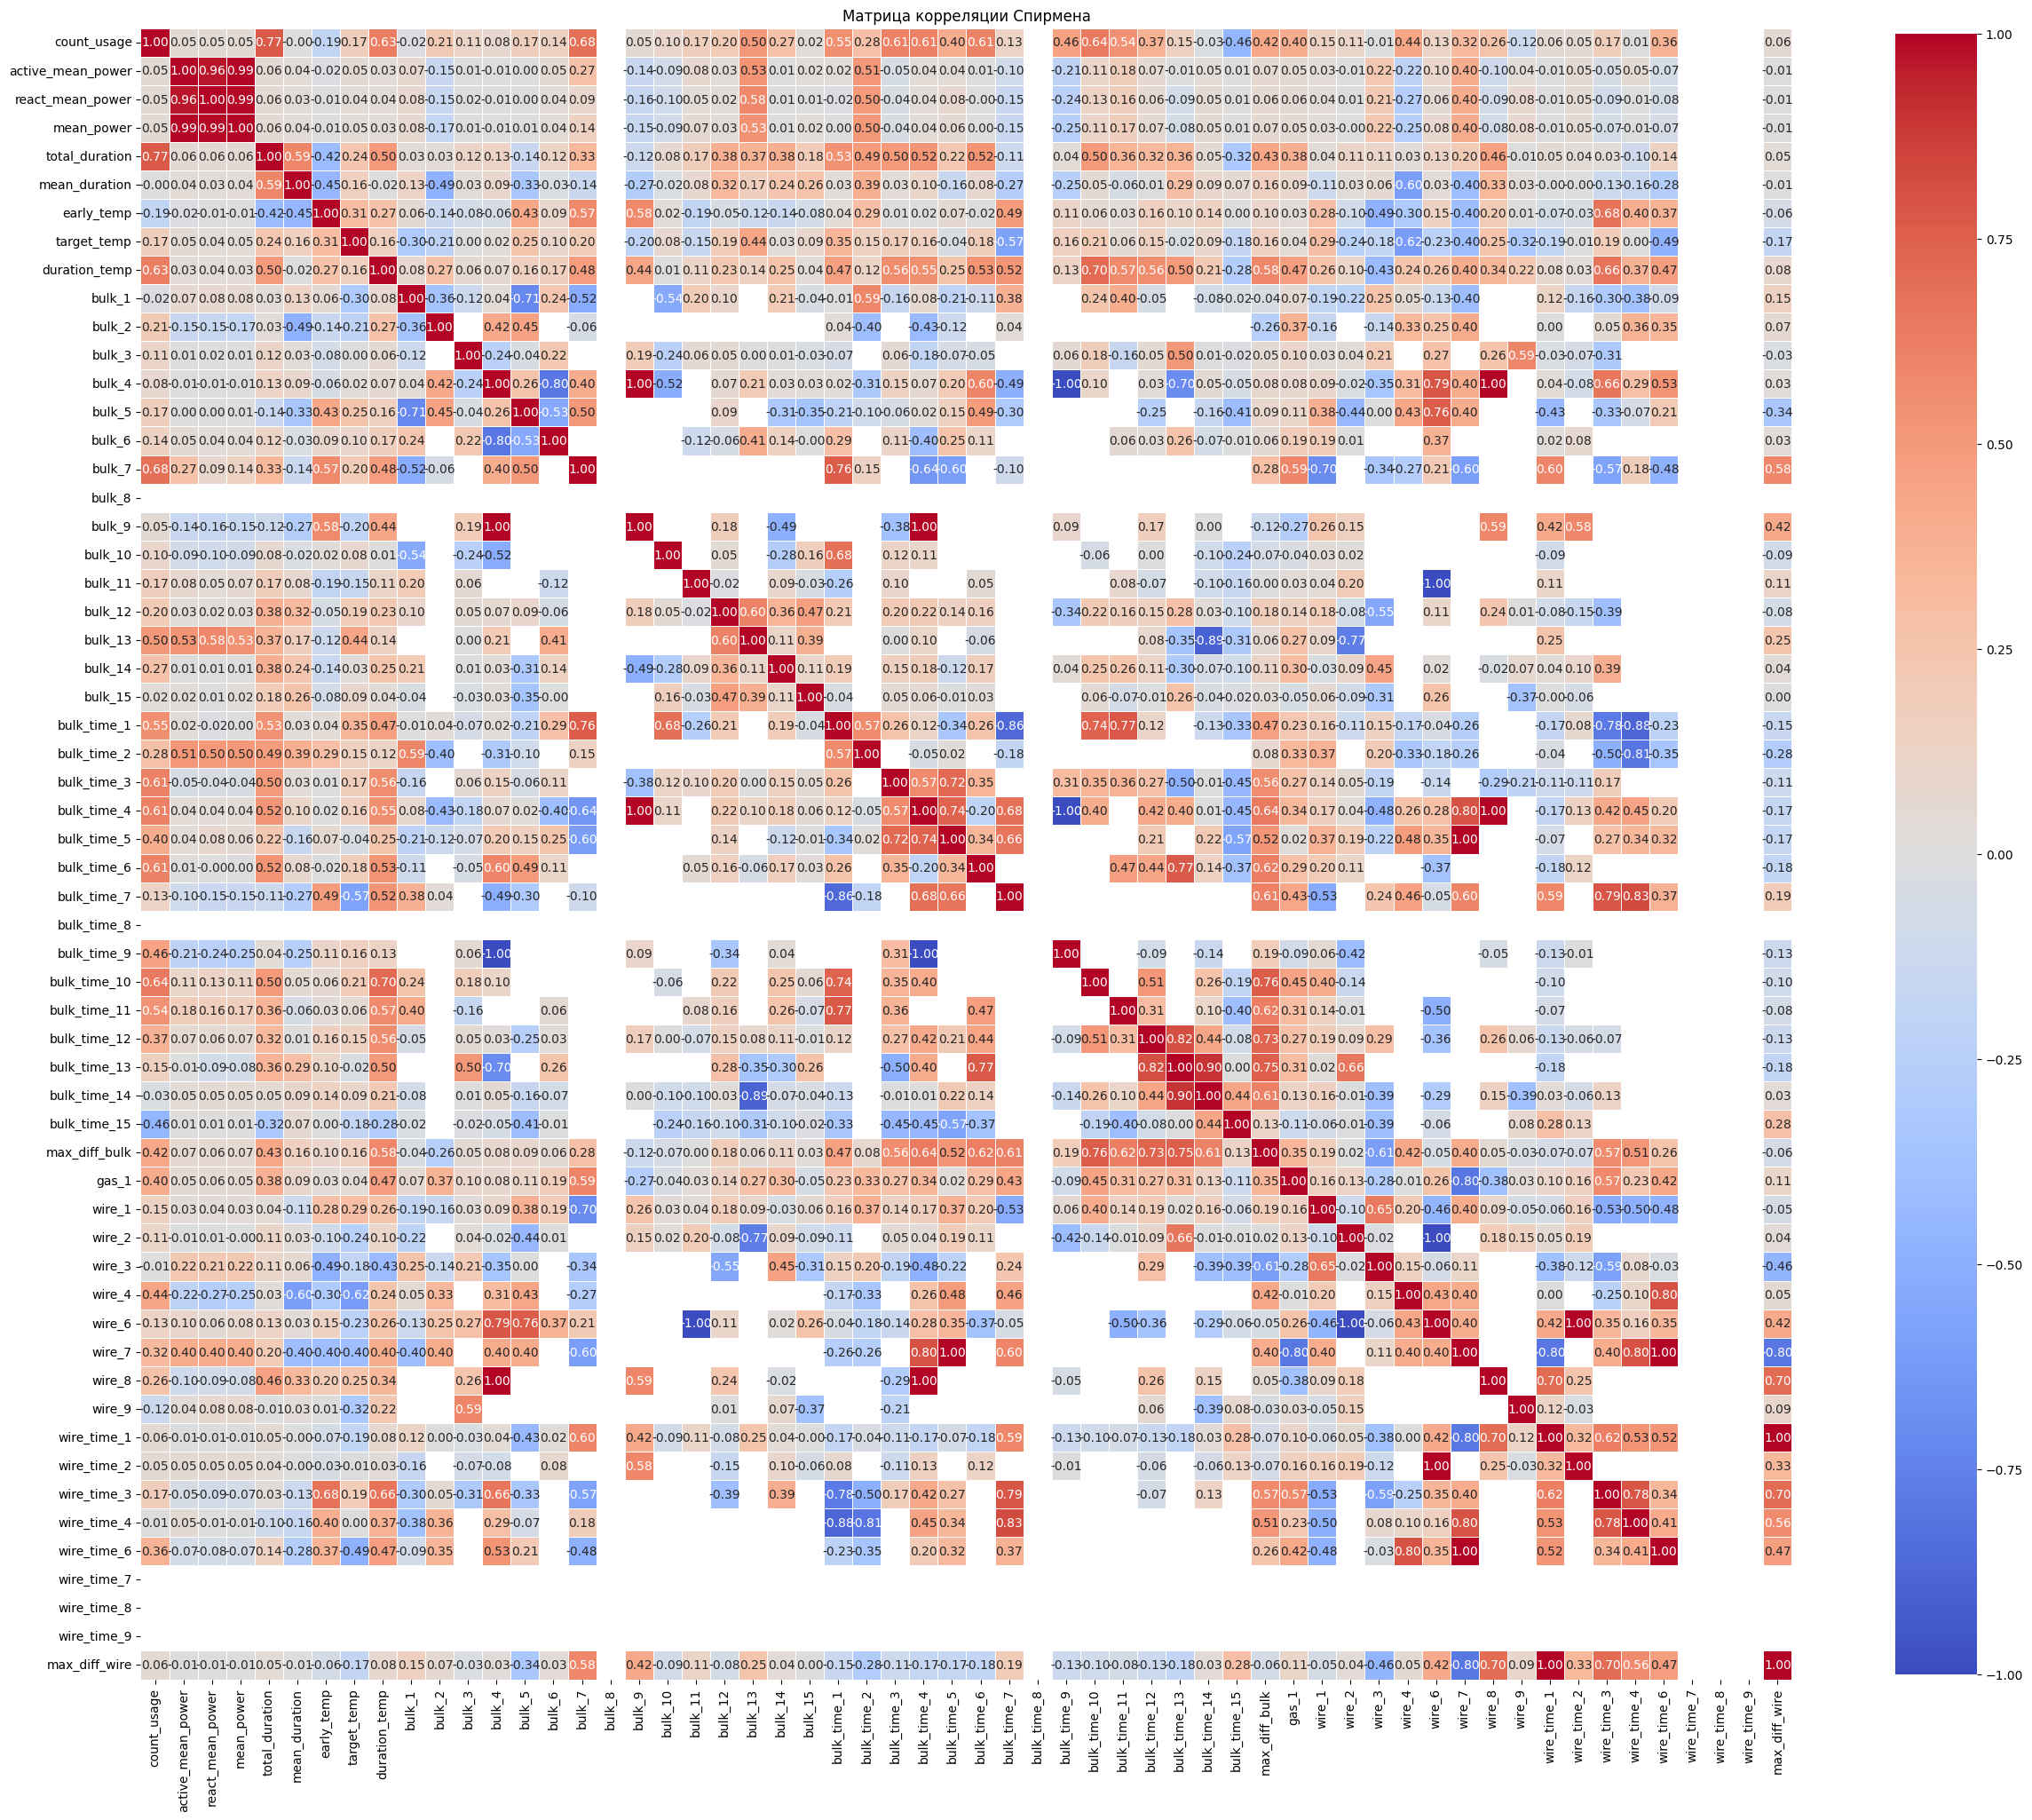

In [220]:
df_corr(df_main.drop(columns='key'))

Чтобы частично устранить мультиколлинеарность входящих признаков, уберем из датасета столбцы активной и реактивной мощности. Корреляция с целевым признаком отсутствует

In [221]:
df_main.drop(columns=['key', 'active_mean_power', 'react_mean_power'], inplace=True)

In [222]:
df_main.reset_index(drop=True, inplace=True)

### Разделение на тренировочную и тестовую выборки

In [223]:
X = df_main.drop(columns='target_temp')
y = df_main['target_temp']

In [224]:
X_train_original, X_test_original, y_train, y_test = train_test_split(X, y,
                                                    test_size = TEST_SIZE, 
                                                    random_state=RANDOM_STATE,
                                                    )

In [225]:
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0, add_indicator=True)),
    ('scaler', StandardScaler()),
])

X_train = preprocessor.fit_transform(X_train_original)
X_test = preprocessor.transform(X_test_original)


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:572: FutureWarning: Currently, when `keep_empty_feature=False` and `strategy="constant"`, empty features are not dropped. This behaviour will change in version 1.8. Set `keep_empty_feature=True` to preserve this behaviour.
  warnings.warn(


### Промежуточный вывод

Данные подготовлены. 
- Таблицы были объединены, некоректные данные убраны из выборки. 
- Выборка проверена на адекватность. 
- Данные разделены на тренировочную и тестовую выборки и отмасштабированы

## Обучение моделей

### Дерево решений

In [226]:
pipe_final = Pipeline([
    ('models', DecisionTreeRegressor(random_state=RANDOM_STATE))
])

In [227]:
param_grid_tree = [
    {
        'models': [DecisionTreeRegressor(random_state=RANDOM_STATE,
                                          )],
        'models__max_depth': range(2,100),
        'models__max_features': range(2,100),
        'models__min_samples_split':range(5,100),
        'models__min_samples_leaf':range(5,100),
    }
]

In [228]:
randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_grid_tree, 
    cv=5,
    n_iter=500,
    scoring=['neg_mean_absolute_error'],
    refit='neg_mean_absolute_error',
    random_state=RANDOM_STATE,
    )

In [229]:
%%time
randomized_search.fit(X_train, y_train)

tree_model = randomized_search.best_estimator_
print('Лучшая модель и её параметры:\n\n')
tree_model

Лучшая модель и её параметры:


CPU times: user 14.7 s, sys: 0 ns, total: 14.7 s
Wall time: 14.7 s


Pipeline(steps=[('models',
                 DecisionTreeRegressor(max_depth=50, max_features=57,
                                       min_samples_leaf=19,
                                       min_samples_split=61,
                                       random_state=200726))])

In [230]:
tree_score = randomized_search.best_score_
print(f'Метрика MAE: {tree_score:.4f}')

Метрика MAE: -7.0545


### Catboost

In [231]:
cv_dataset = Pool(data=X_train_original,
                  label=y_train
                  )

In [232]:
def objective(trial, X, y):
    params = {
        "iterations": trial.suggest_int("iterations", 1, 1000, step=1),
        "depth": trial.suggest_int("depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 15, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 2),
        "random_strength": trial.suggest_float("random_strength", 1e-5, 10, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "border_count": trial.suggest_int("border_count", 32, 224, step=32),
        "boosting_type": "Ordered",
        "loss_function": "RMSE",
        "eval_metric": "MAE",
        "verbose": False,
        "random_seed": RANDOM_STATE,
        "early_stopping_rounds": 50,
        "task_type": "GPU",
        "devices": "0",
        'gpu_ram_part': 0.75
    }

    # Выполнение кросс-валидации
    cv_results = cv(
        pool=cv_dataset,
        params=params,
        fold_count=5,
        partition_random_seed=RANDOM_STATE,
        shuffle=True,
        plot=False,
        verbose=False
    )

    return cv_results["test-MAE-mean"].min()

In [233]:
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
objective_with_data = functools.partial(objective, X=X_train_original, y=y_train)
study.optimize(objective_with_data, n_trials=20, show_progress_bar=True)

catboost_best_params = study.best_params
catboost_best_value = study.best_value

print(f"Лучшие параметры: {catboost_best_params}")
print(f"Лучшее значение MAE: {catboost_best_value:.4f}")

[I 2026-07-31 15:21:10,027] A new study created in memory with name: no-name-7801f528-1f8e-46d7-b28c-85e91142119c


  0%|          | 0/20 [00:00<?, ?it/s]

Default metric period is 5 because MAE is/are not implemented for GPU


Training on fold [0/5]
bestTest = 63.58616135
bestIteration = 383
Training on fold [1/5]
bestTest = 60.75645818
bestIteration = 383
Training on fold [2/5]
bestTest = 61.44800647
bestIteration = 383
Training on fold [3/5]
bestTest = 61.35029409
bestIteration = 383
Training on fold [4/5]
bestTest = 62.73411683
bestIteration = 383
[I 2026-07-31 15:21:26,830] Trial 0 finished with value: 61.97500738460462 and parameters: {'iterations': 384, 'depth': 8, 'learning_rate': 0.008495545860968517, 'l2_leaf_reg': 1.5054639566522163, 'bagging_temperature': 0.6113072086201861, 'random_strength': 0.028400550312873373, 'min_child_samples': 17, 'border_count': 64}. Best is trial 0 with value: 61.97500738460462.


Default metric period is 5 because MAE is/are not implemented for GPU


...

Training on fold [0/5]
bestTest = 6.084143871
bestIteration = 953
Training on fold [1/5]
bestTest = 5.925292269
bestIteration = 937
Training on fold [2/5]
bestTest = 5.558942422
bestIteration = 953
Training on fold [3/5]
bestTest = 6.080516596
bestIteration = 941
Training on fold [4/5]
bestTest = 5.900593374
bestIteration = 945
[I 2026-07-31 15:24:22,048] Trial 17 finished with value: 5.9108419516268516 and parameters: {'iterations': 954, 'depth': 5, 'learning_rate': 0.01846892668140331, 'l2_leaf_reg': 3.7763739622086225, 'bagging_temperature': 0.4064711402397503, 'random_strength': 3.701899249842413e-05, 'min_child_samples': 28, 'border_count': 160}. Best is trial 17 with value: 5.9108419516268516.


Default metric period is 5 because MAE is/are not implemented for GPU


Training on fold [0/5]
bestTest = 6.170115649
bestIteration = 996
Training on fold [1/5]
bestTest = 5.882742546
bestIteration = 996
Training on fold [2/5]
bestTest = 5.525485686
bestIteration = 999
Training on fold [3/5]
bestTest = 6.168076789
bestIteration = 998
Training on fold [4/5]
bestTest = 5.933738972
bestIteration = 999
[I 2026-07-31 15:24:41,849] Trial 18 finished with value: 5.936272197113173 and parameters: {'iterations': 1000, 'depth': 5, 'learning_rate': 0.01652826462887525, 'l2_leaf_reg': 3.959379658009924, 'bagging_temperature': 0.7683411252818009, 'random_strength': 4.343510346133436e-05, 'min_child_samples': 23, 'border_count': 96}. Best is trial 17 with value: 5.9108419516268516.


Default metric period is 5 because MAE is/are not implemented for GPU


Training on fold [0/5]
bestTest = 14.38810664
bestIteration = 988
Training on fold [1/5]
bestTest = 9.406780953
bestIteration = 977
Training on fold [2/5]
bestTest = 11.14732203
bestIteration = 988
Training on fold [3/5]
bestTest = 10.07238208
bestIteration = 699
Training on fold [4/5]
bestTest = 12.02997037
bestIteration = 988
[I 2026-07-31 15:25:05,048] Trial 19 finished with value: 11.414458343432488 and parameters: {'iterations': 989, 'depth': 6, 'learning_rate': 0.013059904596949798, 'l2_leaf_reg': 5.014185233722248, 'bagging_temperature': 0.855911581345816, 'random_strength': 7.450367632500828, 'min_child_samples': 22, 'border_count': 96}. Best is trial 17 with value: 5.9108419516268516.
Лучшие параметры: {'iterations': 954, 'depth': 5, 'learning_rate': 0.01846892668140331, 'l2_leaf_reg': 3.7763739622086225, 'bagging_temperature': 0.4064711402397503, 'random_strength': 3.701899249842413e-05, 'min_child_samples': 28, 'border_count': 160}
Лучшее значение MAE: 5.9108


### Полносвязная нейронная сеть

In [234]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Тестовая выборка не участвует в подборе гиперпараметров.
X_nn_train_raw, X_nn_valid_raw, y_nn_train_raw, y_nn_valid_raw = train_test_split(
    X_train_original,
    y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

nn_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0, add_indicator=True)),
    ('scaler', StandardScaler()),
])
X_nn_train = nn_preprocessor.fit_transform(X_nn_train_raw).astype(np.float32)
X_nn_valid = nn_preprocessor.transform(X_nn_valid_raw).astype(np.float32)
X_nn_test = nn_preprocessor.transform(X_test_original).astype(np.float32)

# Масштабирование таргета стабилизирует обучение сети.
target_scaler = StandardScaler()
y_nn_train = target_scaler.fit_transform(y_nn_train_raw.to_numpy().reshape(-1, 1)).astype(np.float32).ravel()
y_nn_valid = target_scaler.transform(y_nn_valid_raw.to_numpy().reshape(-1, 1)).astype(np.float32).ravel()
y_nn_test = target_scaler.transform(y_test.to_numpy().reshape(-1, 1)).astype(np.float32).ravel()

for name, values in {
    'X_nn_train': X_nn_train, 'X_nn_valid': X_nn_valid, 'X_nn_test': X_nn_test,
    'y_nn_train': y_nn_train, 'y_nn_valid': y_nn_valid, 'y_nn_test': y_nn_test,
}.items():
    assert np.isfinite(values).all(), f'{name} содержит NaN или Inf'

# Тензоры хранятся на CPU и переносятся на GPU по батчам.
X_train_t = torch.from_numpy(X_nn_train)
y_train_t = torch.from_numpy(y_nn_train)
X_valid_t = torch.from_numpy(X_nn_valid)
y_valid_t = torch.from_numpy(y_nn_valid)
X_test_t = torch.from_numpy(X_nn_test)
y_test_t = torch.from_numpy(y_nn_test)

train_dataset = TensorDataset(X_train_t, y_train_t)
valid_dataset = TensorDataset(X_valid_t, y_valid_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

input_dim = X_train_t.shape[1]

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:572: FutureWarning: Currently, when `keep_empty_feature=False` and `strategy="constant"`, empty features are not dropped. This behaviour will change in version 1.8. Set `keep_empty_feature=True` to preserve this behaviour.
  warnings.warn(


In [235]:
def create_model(n_neurons, dropout_p, use_bn, use_dp):
    layers = []
    for i in range(1, len(n_neurons)-1):
        layers.append(nn.Linear(n_neurons[i-1], n_neurons[i]))
        if use_bn:
            layers.append(nn.BatchNorm1d(n_neurons[i]))
        layers.append(nn.ReLU())
        if use_dp:
            layers.append(nn.Dropout(dropout_p))
    layers.append(nn.Linear(n_neurons[-2], n_neurons[-1]))
    net = nn.Sequential(*layers)

    def init_weights(m):
        if isinstance(m, nn.Linear):
            if m is net[-1]:  # выходной слой
                nn.init.xavier_uniform_(m.weight)
            else:
                nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu')
            nn.init.zeros_(m.bias)
    net.apply(init_weights)
    return net

In [236]:
def objective(trial):
    torch.manual_seed(RANDOM_STATE)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RANDOM_STATE)

    num_epochs = trial.suggest_int('num_epochs', 40, 200)
    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-7, 1e-3, log=True)
    dropout_p = trial.suggest_float('dropout_p', 0.05, 0.5)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128, 256])
    use_bn = trial.suggest_categorical('use_bn', [True, False])

    num_hidden_layers = trial.suggest_int('num_hidden_layers', 1, 3)
    n_neurons = [input_dim]
    for i in range(num_hidden_layers):
        n_neurons.append(
            trial.suggest_categorical(f'hidden_{i}', [32, 64, 128, 256, 512])
        )
    n_neurons.append(1)

    loader_kwargs = {
        'batch_size': batch_size,
        'pin_memory': torch.cuda.is_available(),
    }
    train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
    valid_loader = DataLoader(valid_dataset, shuffle=False, **loader_kwargs)

    model = create_model(n_neurons, dropout_p, use_bn, use_dp=True).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=lr, weight_decay=weight_decay
    )
    loss_fn = nn.MSELoss()
    target_scale = float(target_scaler.scale_[0])
    best_valid_mae = float('inf')
    best_epoch = 1
    epochs_without_improvement = 0
    patience = 20

    for epoch in range(num_epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            preds = model(X_batch).flatten()
            loss = loss_fn(preds, y_batch)
            if not torch.isfinite(loss):
                raise optuna.TrialPruned('Получен NaN/Inf в функции потерь')
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

        model.eval()
        absolute_error = 0.0
        n_objects = 0
        with torch.no_grad():
            for X_batch, y_batch in valid_loader:
                X_batch = X_batch.to(device, non_blocking=True)
                y_batch = y_batch.to(device, non_blocking=True)
                preds = model(X_batch).flatten()
                absolute_error += torch.sum(torch.abs(preds - y_batch)).item()
                n_objects += y_batch.numel()

        # Вычисляем MAE в исходных единицах температуры
        valid_mae = (absolute_error / n_objects) * target_scale
        if not np.isfinite(valid_mae):
            raise optuna.TrialPruned('Получен NaN/Inf на validation')

        trial.report(valid_mae, step=epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        if valid_mae < best_valid_mae - 1e-4:
            best_valid_mae = valid_mae
            best_epoch = epoch + 1
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    trial.set_user_attr('best_epoch', best_epoch)
    return best_valid_mae

In [237]:
%%time
nn_study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10),
)
nn_study.optimize(objective, n_trials=50, show_progress_bar=True)

nn_score = nn_study.best_value

print("Лучшие параметры:", nn_study.best_params)
print("Лучший MAE на валидации:", nn_study.best_value)

[I 2026-07-31 15:25:06,235] A new study created in memory with name: no-name-142515a3-c33a-43d5-ad95-e7a0e173cadc


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-31 15:25:11,162] Trial 0 finished with value: 6.075478749784994 and parameters: {'num_epochs': 101, 'lr': 0.0018460683241384968, 'weight_decay': 3.7567573259738625e-07, 'dropout_p': 0.11798083259957695, 'batch_size': 64, 'use_bn': False, 'num_hidden_layers': 3, 'hidden_0': 512, 'hidden_1': 32, 'hidden_2': 128}. Best is trial 0 with value: 6.075478749784994.
[I 2026-07-31 15:25:12,051] Trial 1 finished with value: 6.405282977120762 and parameters: {'num_epochs': 75, 'lr': 0.0018925013384166027, 'weight_decay': 2.0083410664375614e-05, 'dropout_p': 0.1540803214182309, 'batch_size': 64, 'use_bn': False, 'num_hidden_layers': 1, 'hidden_0': 512}. Best is trial 0 with value: 6.075478749784994.
[I 2026-07-31 15:25:13,313] Trial 2 finished with value: 5.953457963671983 and parameters: {'num_epochs': 147, 'lr': 0.004689233274391065, 'weight_decay': 8.91068070449387e-05, 'dropout_p': 0.13411332336899387, 'batch_size': 64, 'use_bn': True, 'num_hidden_layers': 2, 'hidden_0': 64, 'hidden_

#### Обучение итоговой полносвязной модели

In [238]:
best_params = nn_study.best_params
best_epoch = nn_study.best_trial.user_attrs['best_epoch']

train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=best_params['batch_size'], shuffle=False, pin_memory=torch.cuda.is_available())

n_neurons = [X_nn_train.shape[1]]
n_neurons.extend(
    best_params[f'hidden_{i}'] for i in range(best_params['num_hidden_layers'])
)
n_neurons.append(1)

torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

nn_model = create_model(
    n_neurons, best_params['dropout_p'], best_params['use_bn'], use_dp=True
).to(device)
optimizer = torch.optim.AdamW(
    nn_model.parameters(),
    lr=best_params['lr'],
    weight_decay=best_params['weight_decay'],
)
loss_fn = nn.MSELoss()

for epoch in range(best_epoch):
    nn_model.train()
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        preds = nn_model(X_batch).flatten()
        loss = loss_fn(preds, y_batch)
        if not torch.isfinite(loss):
            raise RuntimeError('NaN/Inf при обучении итоговой модели')
        loss.backward()
        torch.nn.utils.clip_grad_norm_(nn_model.parameters(), max_norm=5.0)
        optimizer.step()

nn_model.eval()

Sequential(
  (0): Linear(in_features=101, out_features=128, bias=True)
  (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.4432268549571856, inplace=False)
  (4): Linear(in_features=128, out_features=1, bias=True)
)

### Выбор лучшей модели

In [239]:
pd.DataFrame(data=[tree_score, catboost_best_value, nn_score], index=['DecisionTree', 'Catboost', 'NN'], columns=['MAE'])

,MAE
DecisionTree,-7.054524
Catboost,5.910842
NN,5.822992


#### Промежуточный результат

Лучшую метрику MAE показала полносвязная нейронная сеть с результатом 5,8229

## Тестирование лучшей модели

In [240]:
test_absolute_error = 0.0
test_n_objects = 0
predicts = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        preds = nn_model(X_batch).flatten()
        predicts.append(preds.cpu())
        test_absolute_error += torch.sum(torch.abs(preds - y_batch)).item()
        test_n_objects += y_batch.numel()

test_mae = (test_absolute_error / test_n_objects) * float(target_scaler.scale_[0])

print(f'Итоговый MAE на тестовой выборке: {test_mae:.4f}')

Итоговый MAE на тестовой выборке: 5.7458


Целевая метрика MAE 6,8 преодолена

### Сравнение результатов лучшей и константной модели

In [241]:
# Объединяем все тензоры в один
all_preds = torch.cat(predicts, dim=0)  # тензор на CPU

# Преобразуем в NumPy и приводим к форме (n_samples, 1) для inverse_transform
preds_np = all_preds.numpy().reshape(-1, 1)

# Обратное масштабирование
preds_original = target_scaler.inverse_transform(preds_np)
preds_flat = [round(float(item[0]), 4) for item in preds_original]

# Теперь preds_original содержит предсказания в исходных единицах
print(preds_flat[:5])


[1582.7062, 1587.2407, 1576.1018, 1586.3906, 1594.4049]


In [242]:
df = pd.DataFrame({
    'y_test': y_test.values,
    'preds': preds_flat,
    'const': round(y_test.mean(),4),
    'err_pred': preds_flat - y_test.values,
    'err_const': round(y_test.mean(),4) - y_test.values,
})
df.head(5)

,y_test,preds,const,err_pred,err_const
0,1573.0,1582.7062,1593.4389,9.7062,20.4389
1,1590.0,1587.2407,1593.4389,-2.7593,3.4389
2,1578.0,1576.1018,1593.4389,-1.8982,15.4389
3,1599.0,1586.3906,1593.4389,-12.6094,-5.5611
4,1591.0,1594.4049,1593.4389,3.4049,2.4389


In [243]:
print(f'Медианная ошибка нейронной сети {round(df['err_pred'].median(),4)}')
print(f'Медианная ошибка константной модели {round(df['err_const'].median(),4)}')

Медианная ошибка нейронной сети 0.1619
Медианная ошибка константной модели 0.4389


#### Промежуточный вывод

Модель нейронной сети уловила некоторые закономерности и по сравнению с константной моделью видно приближение к целевым значениям

### Анализ важности основных признаков

In [244]:
feature_names = nn_preprocessor.get_feature_names_out()

def evaluate(model, X, y):
    model.eval()
    with torch.no_grad():
        device = next(model.parameters()).device
        X = X.to(device)
        y = y.to(device)
        preds = model(X).flatten().cpu().numpy()
        y_np = y.cpu().numpy()
        return mean_absolute_error(y_np, preds)

baseline_mae = evaluate(nn_model, X_test_t, y_test_t)
importances = []
for i in range(X_test_t.shape[1]):
    X_perm = X_test_t.clone()
    perm_idx = torch.randperm(X_perm.shape[0], device=X_perm.device)
    X_perm[:, i] = X_perm[perm_idx, i]
    mae_perm = evaluate(nn_model, X_perm, y_test_t)
    imp = mae_perm - baseline_mae
    importances.append(imp)

feature_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)
print(feature_imp.head(10))

           feature  importance
4       early_temp    0.334143
2   total_duration    0.120371
5    duration_temp    0.076490
3    mean_duration    0.074788
0      count_usage    0.037057
38          wire_1    0.018641
6           bulk_1    0.010344
36   max_diff_bulk    0.008917
39          wire_2    0.008501
19         bulk_14    0.007102


По результату анализа важности признаков на первые места вышли признаки начальной температуры, полного времени нагрева, промежуток времени между замерами, средняя длительность нагрева и количество отдельных итераций нагрева

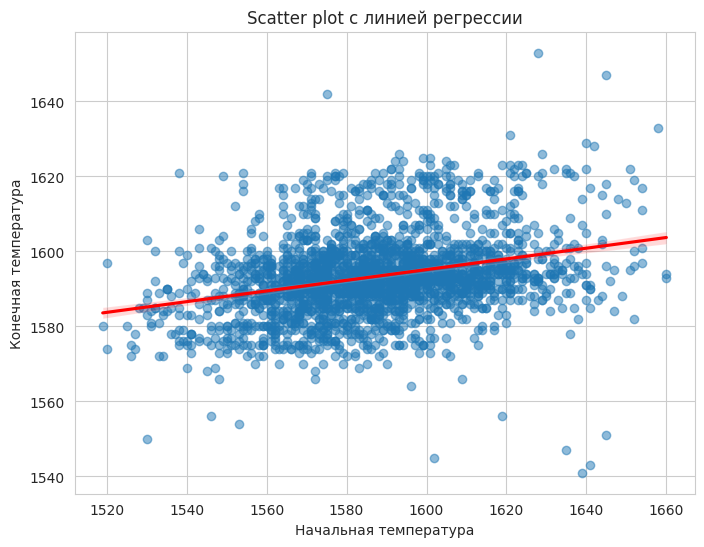

In [245]:
sns.set_style('whitegrid')
plt.figure(figsize=(8, 6))
sns.regplot(data=df_main, x='early_temp', y='target_temp', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.xlabel('Начальная температура')
plt.ylabel('Конечная температура')
plt.title('Scatter plot с линией регрессии')
plt.show()

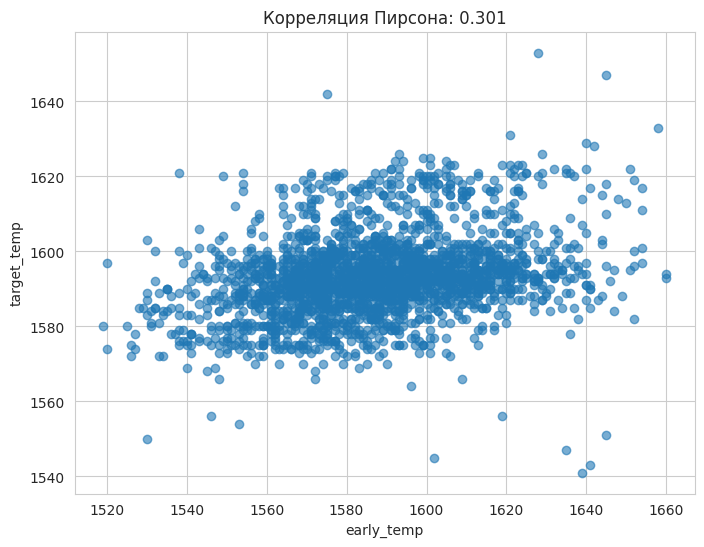

In [246]:
corr = df_main['early_temp'].corr(df_main['target_temp'])

plt.figure(figsize=(8, 6))
plt.scatter(df_main['early_temp'], df_main['target_temp'], alpha=0.6)
plt.xlabel('early_temp')
plt.ylabel('target_temp')
plt.title(f'Корреляция Пирсона: {corr:.3f}')
plt.grid(True)
plt.show()

Конечная температура по итогу сильнее всего зависит от начальной температуры сплава

## Вывод

По итогу работы была построена модель (полносвязная нейронная сеть) прогнозирования конечной температуры сплава. 

В результате обучения модели была достигнута целевая метрика MAE не более 6.8 со значением метрики на тестовых данных 5.8752

При подготовке данных были исследованы и проанализированы все таблицы SQLite, подготовлены данные для обучения, подготовлены тренировочные, валидационные и тестовые выборки.

По итогу самым важным фактором, влияющим на конечную температуру сплава, оказалась начальная температура, наиболее влияющая на прогнозирование.

При прогнозировании конечной температуры прошу обратить внимание на первые 5 по важности признаки: начальная температура, полное время нагрева, промежуток времени между замерами, средняя длительность нагрева и количество отдельных итераций нагрева